# Install Packages

In [ ]:
!pip install --force-reinstall numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 74.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
!pip install pymc==4.1.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.1/543.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.7 MB/s eta 0:00:00
  Attempting uninstall: pymc
    Found existing installation: pymc 5.20.1
    Uninstalling pymc-5.20.1:
      Successfully uninstalled pymc-5.20.1


# Import libraries

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt

from numba import njit
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import least_squares
from scipy.signal import detrend, savgol_filter

import os

THEANO_FLAGS = "optimizer=fast_compile"

print(f"PyMC3 Version: {pm.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"PyTensor Version: {pytensor.__version__}")

PyMC3 Version: 5.21.1
NumPy Version: 1.26.4
PyTensor Version: 2.28.3


# Lynx-Hare Data

In [ ]:
# fmt: off
data = pd.DataFrame(dict(
    year = np.arange(1900., 1921., 1),
    lynx = np.array([4.0, 6.1, 9.8, 35.2, 59.4, 41.7, 19.0, 13.0, 8.3, 9.1, 7.4,
                8.0, 12.3, 19.5, 45.7, 51.1, 29.7, 15.8, 9.7, 10.1, 8.6]),
    hare = np.array([30.0, 47.2, 70.2, 77.4, 36.3, 20.6, 18.1, 21.4, 22.0, 25.4,
                 27.1, 40.3, 57.0, 76.6, 52.3, 19.5, 11.2, 7.6, 14.6, 16.2, 24.7])))
data.head()
# fmt: on

,year,lynx,hare
0,1900.0,4.0,30.0
1,1901.0,6.1,47.2
2,1902.0,9.8,70.2
3,1903.0,35.2,77.4
4,1904.0,59.4,36.3


# Explore Data

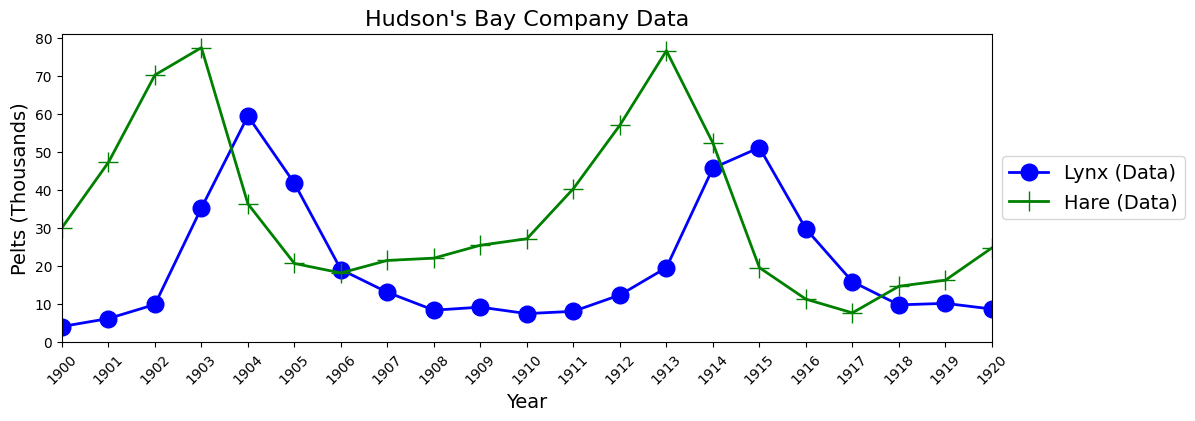

In [ ]:
# plot data function for reuse later
def plot_data(ax, lw=2, title="Hudson's Bay Company Data"):
    ax.plot(data.year, data.lynx, color="b", lw=lw, marker="o", markersize=12, label="Lynx (Data)")
    ax.plot(data.year, data.hare, color="g", lw=lw, marker="+", markersize=14, label="Hare (Data)")
    ax.legend(fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_xlim([1900, 1920])
    ax.set_ylim(0)
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Pelts (Thousands)", fontsize=14)
    ax.set_xticks(data.year.astype(int))
    ax.set_xticklabels(ax.get_xticks(), rotation=45)
    ax.set_title(title, fontsize=16)
    return ax

_, ax = plt.subplots(figsize=(12, 4))
plot_data(ax);

# ODE Int

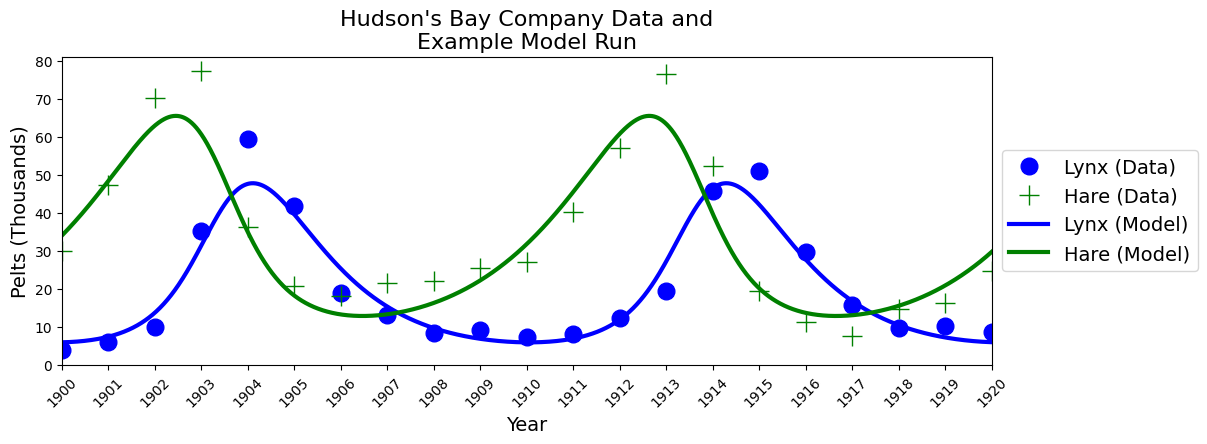

In [ ]:
# define the right hand side of the ODE equations in the Scipy odeint signature
from numba import njit


@njit
def rhs(X, t, theta):
    # unpack parameters
    x, y = X
    alpha, beta, gamma, delta, xt0, yt0 = theta
    # equations
    dx_dt = alpha * x - beta * x * y
    dy_dt = -gamma * y + delta * x * y
    return [dx_dt, dy_dt]

# plot model function
def plot_model(
    ax,
    x_y,
    time=np.arange(1900, 1921, 0.01),
    alpha=1,
    lw=3,
    title="Hudson's Bay Company Data and\nExample Model Run",
):
    ax.plot(time, x_y[:, 1], color="b", alpha=alpha, lw=lw, label="Lynx (Model)")
    ax.plot(time, x_y[:, 0], color="g", alpha=alpha, lw=lw, label="Hare (Model)")
    ax.legend(fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, fontsize=16)
    return ax

# note theta = alpha, beta, gamma, delta, xt0, yt0
theta = np.array([0.52, 0.026, 0.84, 0.026, 34.0, 5.9])
time = np.arange(1900, 1921, 0.01)

# call Scipy's odeint function
x_y = odeint(func=rhs, y0=theta[-2:], t=time, args=(theta,))

# plot
_, ax = plt.subplots(figsize=(12, 4))
plot_data(ax, lw=0)
plot_model(ax, x_y);


# Least Squares to find $\theta$ params

In [ ]:
# function that calculates residuals based on a given theta
def ode_model_resid(theta):
    return (
        data[["hare", "lynx"]] - odeint(func=rhs, y0=theta[-2:], t=data.year, args=(theta,))
    ).values.flatten()

# calculate least squares using the Scipy solver
results = least_squares(ode_model_resid, x0=theta)

# put the results in a dataframe for presentation and convenience
df = pd.DataFrame()
parameter_names = ["alpha", "beta", "gamma", "delta", "h0", "l0"]
df["Parameter"] = parameter_names
df["Least Squares Solution"] = results.x
df.round(2)

,Parameter,Least Squares Solution
0,alpha,0.48
1,beta,0.02
2,gamma,0.93
3,delta,0.03
4,h0,34.91
5,l0,3.86


We are able to reproduce the parameters using this least squares approach.

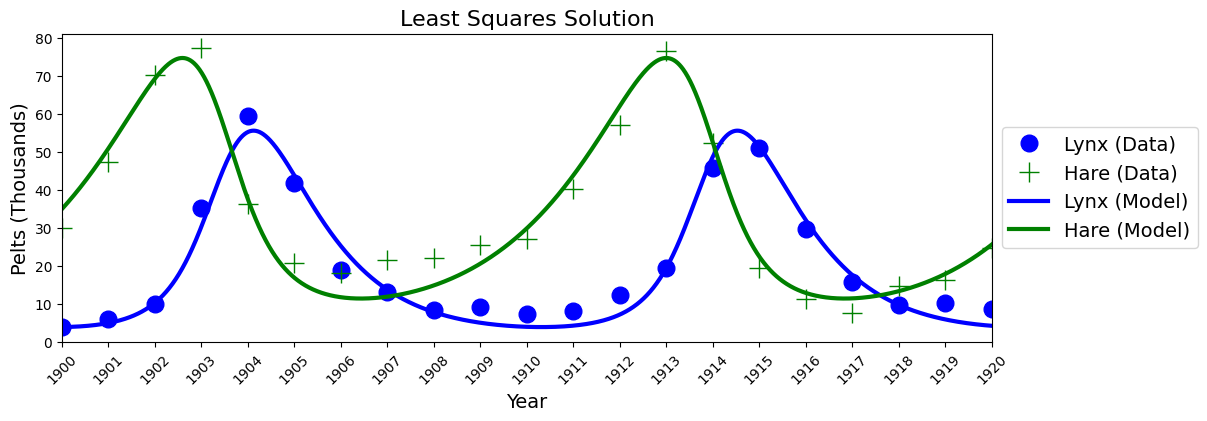

In [ ]:
time = np.arange(1900, 1921, 0.01)
theta = results.x
x_y = odeint(func=rhs, y0=theta[-2:], t=time, args=(theta,))
fig, ax = plt.subplots(figsize=(12, 4))
plot_data(ax, lw=0)
plot_model(ax, x_y, title="Least Squares Solution");

# Bayesian Inference 2-Species Lotka-Volterra 1

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    return odeint(func=rhs,
                  y0=theta[-2:],
                  t=data.year,
                  args=(theta,)
                  )


In [ ]:
theta = results.x  # least squares solution used to inform the priors
with pm.Model() as model:

    # Priors
    alpha = pm.TruncatedNormal("alpha", mu=theta[0], sigma=0.1, lower=0, initval=theta[0])
    beta = pm.TruncatedNormal("beta", mu=theta[1], sigma=0.01, lower=0, initval=theta[1])
    gamma = pm.TruncatedNormal("gamma", mu=theta[2], sigma=0.1, lower=0, initval=theta[2])
    delta = pm.TruncatedNormal("delta", mu=theta[3], sigma=0.01, lower=0, initval=theta[3])
    xt0 = pm.TruncatedNormal("xto", mu=theta[4], sigma=1, lower=0, initval=theta[4])
    yt0 = pm.TruncatedNormal("yto", mu=theta[5], sigma=1, lower=0, initval=theta[5])
    sigma = pm.HalfNormal("sigma", 10)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack([alpha, beta, gamma, delta, xt0, yt0])
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=data[["hare", "lynx"]].values)

# Bayesian Inference 2-Species Lotka Volterra 2

http://pymc.io/projects/examples/en/latest/ode_models/ODE_with_manual_gradients.html#handling-ode-gradients

In [ ]:
n_states = 2
n_odeparams = 4
n_ivs = 2


class LotkaVolterraModel:
    def __init__(self, n_states, n_odeparams, n_ivs, y0=None):
        self._n_states = n_states
        self._n_odeparams = n_odeparams
        self._n_ivs = n_ivs
        self._y0 = y0

    def simulate(self, parameters, times):
        return self._simulate(parameters, times, False)

    def simulate_with_sensitivities(self, parameters, times):
        return self._simulate(parameters, times, True)

    def _simulate(self, parameters, times, sensitivities):
        alpha, beta, gamma, delta, Xt0, Yt0 = [x for x in parameters]

        def r(y, t, p):
            X, Y = y
            dX_dt = alpha * X - beta * X * Y
            dY_dt = -gamma * Y + delta * X * Y
            return dX_dt, dY_dt

        if sensitivities:

            def jac(y):
                X, Y = y
                ret = np.zeros((self._n_states, self._n_states))
                ret[0, 0] = alpha - beta * Y
                ret[0, 1] = -beta * X
                ret[1, 0] = delta * Y
                ret[1, 1] = -gamma + delta * X
                return ret

            def dfdp(y):
                X, Y = y
                ret = np.zeros(
                    (self._n_states, self._n_odeparams + self._n_ivs)
                )  # except the following entries
                ret[0, 0] = (
                    X  # \frac{\partial  [\alpha X - \beta XY]}{\partial \alpha}, and so on...
                )
                ret[0, 1] = -X * Y
                ret[1, 2] = -Y
                ret[1, 3] = X * Y

                return ret

            def rhs(y_and_dydp, t, p):
                y = y_and_dydp[0 : self._n_states]
                dydp = y_and_dydp[self._n_states :].reshape(
                    (self._n_states, self._n_odeparams + self._n_ivs)
                )
                dydt = r(y, t, p)
                d_dydp_dt = np.matmul(jac(y), dydp) + dfdp(y)
                return np.concatenate((dydt, d_dydp_dt.reshape(-1)))

            y0 = np.zeros((2 * (n_odeparams + n_ivs)) + n_states)
            y0[6] = 1.0  # \frac{\partial  [X]}{\partial Xt0} at t==0, and same below for Y
            y0[13] = 1.0
            y0[0:n_states] = [Xt0, Yt0]
            result = odeint(rhs, y0, times, (parameters,), rtol=1e-6, atol=1e-5)
            values = result[:, 0 : self._n_states]
            dvalues_dp = result[:, self._n_states :].reshape(
                (len(times), self._n_states, self._n_odeparams + self._n_ivs)
            )
            return values, dvalues_dp
        else:
            values = odeint(r, [Xt0, Yt0], times, (parameters,), rtol=1e-6, atol=1e-5)
            return values


ode_model = LotkaVolterraModel(n_states, n_odeparams, n_ivs)

# Bayesian Inference Generalized Lotka-Volterra

## Mathematical formulation

Recall that a generalized Lotka-Volterra is the same as the 2-species, but with $n$ species, $n$ need not be 2.

$$\frac{dx(t)}{dt} = D\left(x(t) \right ) \left ( r + A x(t) \right )$$

where

1. $x(t) \in \mathbb{R}^{n \times 1}$ is a column vector of $n$ species
2. $D(x(t))$ transforms the column vector into a diagonal $n \times n$ matrix,
3. $A \in \mathbb{R}^{n \times n}$ is an $n \times n$ vector of interactions amongst the $n$ species' populations,
4. $r \in \mathbb{R}^{n \times 1}$ is an $n$-dimensional column vector of intrinsic growth rates (or death rates if negative) for each species $i$, $i = 1, ..., n$.
5. Hence, $D\left(x(t) \right )$ and $\left ( r + A x(t) \right )$ is a matrix-matrix product, $A$ and $x(t)$ a matrix-vector product, and $r$ and $A x(t)$ a vector element-wise addition.

This yields the dynamics for each population $n$.


**[Reference](https://stefanoallesina.github.io/Theoretical_Community_Ecology/generalized-lotka-volterra-model.html)**


This can map to the 2-species Lotka-Volterra. If

$$\dot{x} = \alpha x - \beta xy,$$
$$\dot{y} = \delta xy - \gamma y.$$

where $\alpha, \beta, \delta, \gamma > 0$. Define $z = \begin{bmatrix} x \\ y \end{bmatrix} \implies \dot{z} = \begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix}$. Hence, if $\odot$ is the Hadamard product, or the elementwise vector product (equivalent to the dot product of the diagonalized left vector and the regular right vector), then

$$\begin{aligned}
  \dot{z}
  &= \begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix} \\
  &= \begin{bmatrix} x \\ y \end{bmatrix}\odot \begin{bmatrix} \alpha - \beta y \\ -\gamma + \delta x \end{bmatrix} \\
  &= \begin{bmatrix} x & 0 \\ 0 & y \end{bmatrix} \left ( \begin{bmatrix} \alpha \\ -\gamma \end{bmatrix} + \begin{bmatrix} -\beta y \\ \delta x \end{bmatrix} \right ) \\
  &= \begin{bmatrix} x & 0 \\ 0 & y \end{bmatrix} \left ( \begin{bmatrix} \alpha \\ -\gamma \end{bmatrix} + \begin{bmatrix} 0 & -\beta \\ \delta & 0 \end{bmatrix}\begin{bmatrix} x \\ y \end{bmatrix} \right ) \\
  &= D(z) \left ( r + A z\right ) \\
\end{aligned}$$

Hence if we let $z = \begin{bmatrix} x \\ y \end{bmatrix} \implies \dot{z} = \begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix}$, $r = \begin{bmatrix} \alpha \\ -\gamma \end{bmatrix}$, and $A = \begin{bmatrix} 0 & -\beta \\ \delta & 0 \end{bmatrix}$ we can formulate the generalized (i.e., $n$-species) Lotka-Volterra with the 2-species Lotka-Volterra. $\square$

**Note** that the definitions of the generalized Lotka-Volterra params still are applicable to the two-sepcies case. $r$ still represents the intrinsic growth rate, where $\gamma$ is the rate of change of the predator population, negative meaning death, and $A$ represents the interactions: $\beta$ is the change of the prey with teh predator, and $\delta$ the change in predator with the prey.

## Implementation of GLV

In [ ]:
# define the right hand side of the ODE equations in the Scipy odeint signature
from numba import njit

# njit
# def rhs(X, t, theta): # goes into odeint
#     # unpack parameters
#     x, y = X
#     alpha, beta, gamma, delta, xt0, yt0 = theta
#     # equations
#     dx_dt = alpha * x - beta * x * y
#     dy_dt = -gamma * y + delta * x * y
#     return [dx_dt, dy_dt]

@njit
def gLV(X, t, r, A):
    return X * (r + A @ X)


## Data and plotting: GLV format, 2-species

In [ ]:
# fmt: off
data = pd.DataFrame(dict(
    year = np.arange(1900., 1921., 1),
    lynx = np.array([4.0, 6.1, 9.8, 35.2, 59.4, 41.7, 19.0, 13.0, 8.3, 9.1, 7.4,
                8.0, 12.3, 19.5, 45.7, 51.1, 29.7, 15.8, 9.7, 10.1, 8.6]),
    hare = np.array([30.0, 47.2, 70.2, 77.4, 36.3, 20.6, 18.1, 21.4, 22.0, 25.4,
                 27.1, 40.3, 57.0, 76.6, 52.3, 19.5, 11.2, 7.6, 14.6, 16.2, 24.7])))
data.head()
# fmt: on

,year,lynx,hare
0,1900.0,4.0,30.0
1,1901.0,6.1,47.2
2,1902.0,9.8,70.2
3,1903.0,35.2,77.4
4,1904.0,59.4,36.3


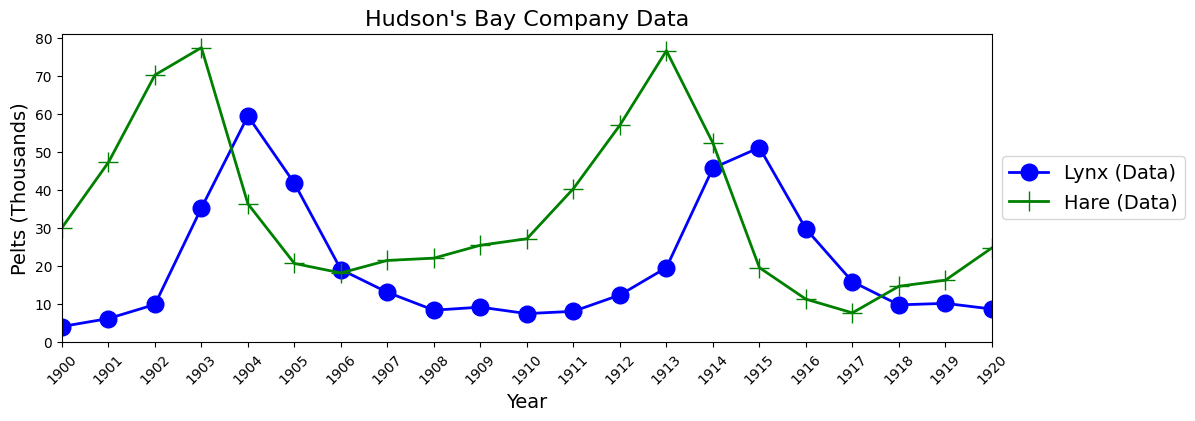

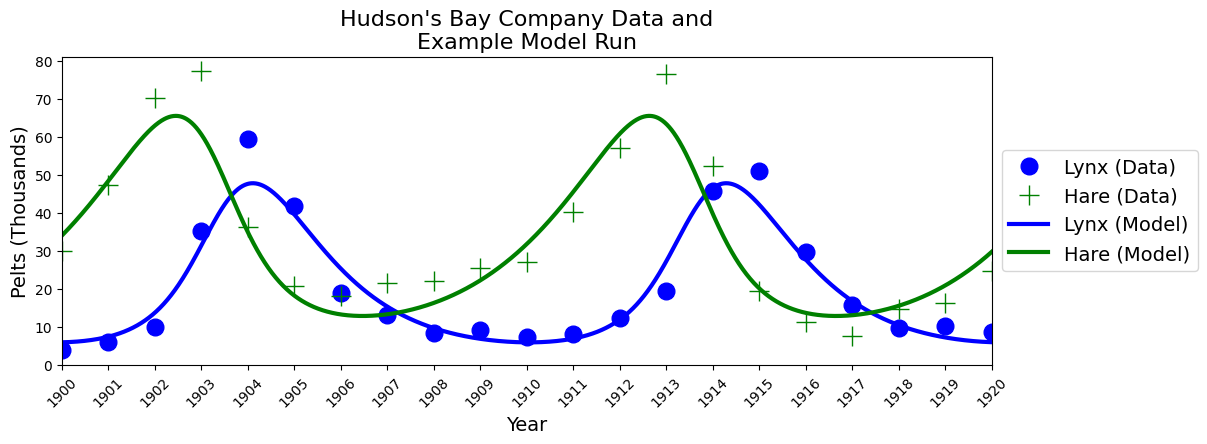

In [ ]:
# plot data function for reuse later
def plot_data(ax, lw=2, title="Hudson's Bay Company Data"):
    ax.plot(data.year, data.lynx, color="b", lw=lw, marker="o", markersize=12, label="Lynx (Data)")
    ax.plot(data.year, data.hare, color="g", lw=lw, marker="+", markersize=14, label="Hare (Data)")
    ax.legend(fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_xlim([1900, 1920])
    ax.set_ylim(0)
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Pelts (Thousands)", fontsize=14)
    ax.set_xticks(data.year.astype(int))
    ax.set_xticklabels(ax.get_xticks(), rotation=45)
    ax.set_title(title, fontsize=16)
    return ax

_, ax = plt.subplots(figsize=(12, 4))
plot_data(ax);

# plot model function
def plot_model(
    ax,
    x_y,
    time=np.arange(1900, 1921, 0.01),
    alpha=1,
    lw=3,
    title="Hudson's Bay Company Data and\nExample Model Run",
):
    ax.plot(time, x_y[:, 1], color="b", alpha=alpha, lw=lw, label="Lynx (Model)")
    ax.plot(time, x_y[:, 0], color="g", alpha=alpha, lw=lw, label="Hare (Model)")
    ax.legend(fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, fontsize=16)
    return ax

# note theta = alpha, beta, gamma, delta, xt0, yt0
alpha = 0.52
beta = 0.026
gamma = 0.84
delta = 0.026
xt0 = 34.0
yt0 = 5.9
theta = np.array([alpha, beta, gamma, delta, xt0, yt0])
time = np.arange(1900, 1921, 0.01)

# gLV params
r = np.array([alpha, -gamma])
A = np.array([[0, -beta], [delta, 0]])

# call Scipy's odeint function
# y0 is the X in the gLV formal parameter list,
# t is the t in the gLV formal parameter list,
#   which isnt really used in the suite of the gLV (or rhs)
#   function itself
x_y = odeint(func=gLV, y0=theta[-2:],
             t=time,
             args=(r, A,))

# plot
_, ax = plt.subplots(figsize=(12, 4))
plot_data(ax, lw=0)
plot_model(ax, x_y);

## GLV 2-Species Least Squres Coupling Param Estimation

In [ ]:
# function that calculates residuals based on a given theta
def ode_model_resid(theta):

    y0 = theta[-2:]
    r = np.array([theta[0], -theta[2]])
    A = np.array([[0, -theta[1]], [theta[3], 0]])

    sol = odeint(func=gLV, y0=theta[-2:],
             t=data.year,
             args=(r, A,))

    return (
        data[["hare", "lynx"]] - sol
    ).values.flatten()

# calculate least squares using the Scipy solver
results_glv2 = least_squares(ode_model_resid, x0=theta)

# put the results in a dataframe for presentation and convenience
df = pd.DataFrame()
parameter_names = ["alpha", "beta", "gamma", "delta", "h0", "l0"]
df["Parameter"] = parameter_names
df["Least Squares Solution"] = results_glv2.x
df.round(2)

,Parameter,Least Squares Solution
0,alpha,0.48
1,beta,0.02
2,gamma,0.93
3,delta,0.03
4,h0,34.91
5,l0,3.86


## GLV 2-Species Bayesian Coupling Param Estimation

### Setting up Bayesian inference graph objects

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    return odeint(func=gLV,
                  y0=theta[-2:],
                  t=data.year,
                  args=(r, A,))


In [ ]:
theta_glv2 = results_glv2.x  # least squares solution used to inform the priors
with pm.Model() as model:

    # Priors
    alpha = pm.TruncatedNormal("alpha", mu=theta_glv2[0], sigma=0.1, lower=0, initval=theta_glv2[0])
    beta = pm.TruncatedNormal("beta", mu=theta_glv2[1], sigma=0.01, lower=0, initval=theta_glv2[1])
    gamma = pm.TruncatedNormal("gamma", mu=theta_glv2[2], sigma=0.1, lower=0, initval=theta_glv2[2])
    delta = pm.TruncatedNormal("delta", mu=theta_glv2[3], sigma=0.01, lower=0, initval=theta_glv2[3])
    xt0 = pm.TruncatedNormal("xto", mu=theta_glv2[4], sigma=1, lower=0, initval=theta_glv2[4])
    yt0 = pm.TruncatedNormal("yto", mu=theta_glv2[5], sigma=1, lower=0, initval=theta_glv2[5])
    sigma = pm.HalfNormal("sigma", 10)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack([alpha, beta, gamma, delta, xt0, yt0])
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=data[["hare", "lynx"]].values)

### Plotting Functions

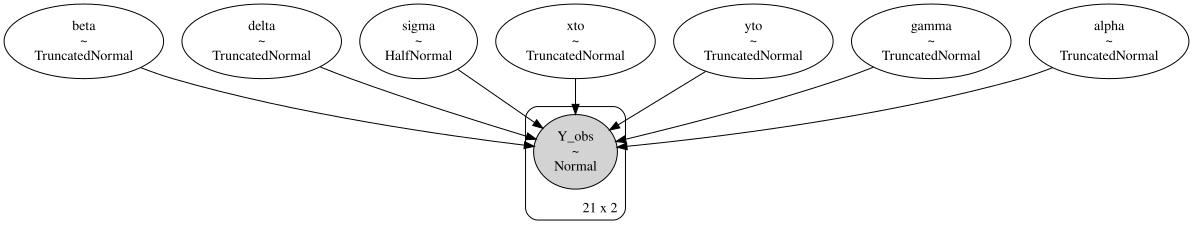

In [ ]:
pm.model_to_graphviz(model=model)

In [ ]:
def plot_model_trace(ax, trace_df, row_idx, lw=1, alpha=0.2):
    cols = ["alpha", "beta", "gamma", "delta", "xto", "yto"]
    row = trace_df.iloc[row_idx, :][cols].values

    # alpha, beta, gamma, delta, Xt0, Yt0
    time = np.arange(1900, 1921, 0.01)
    theta = row
    r = np.array([theta[0], -theta[2]])
    A = np.array([[0, -theta[1]], [theta[3], 0]])

    x_y = odeint(func=gLV,
                 y0=theta[-2:],
                 t=data.year,
                 args=(r, A,))
    plot_model(ax, x_y, time=time, lw=lw, alpha=alpha);

def plot_inference(
    ax,
    trace,
    num_samples=25,
    title="Hudson's Bay Company Data and\nInference Model Runs",
    plot_model_kwargs=dict(lw=1, alpha=0.2),
):
    trace_df = az.extract(trace, num_samples=num_samples).to_dataframe()
    plot_data(ax, lw=0)
    for row_idx in range(num_samples):
        plot_model_trace(ax, trace_df, row_idx, **plot_model_kwargs)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, fontsize=16)



### Bayesian Inference

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

In [ ]:
# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 2000

# Inference!
with model:
    trace_slice = pm.sample(step=[pm.Slice(vars_list)], tune=tune, draws=draws)

trace = trace_slice
az.summary(trace)

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.482,0.023,0.439,0.523,0.003,0.002,73.0,140.0,1.02
beta,0.025,0.001,0.023,0.028,0.000,0.000,165.0,288.0,1.01
delta,0.028,0.002,0.025,0.030,0.000,0.000,77.0,147.0,1.02
gamma,0.928,0.050,0.838,1.015,0.006,0.004,72.0,121.0,1.02
sigma,4.107,0.484,3.274,5.050,0.009,0.006,3027.0,3026.0,1.00
xto,34.916,0.826,33.333,36.426,0.034,0.024,595.0,1257.0,1.00
yto,3.874,0.464,2.989,4.741,0.040,0.029,132.0,212.0,1.01


### Plot Bayesian Inference Params and Results

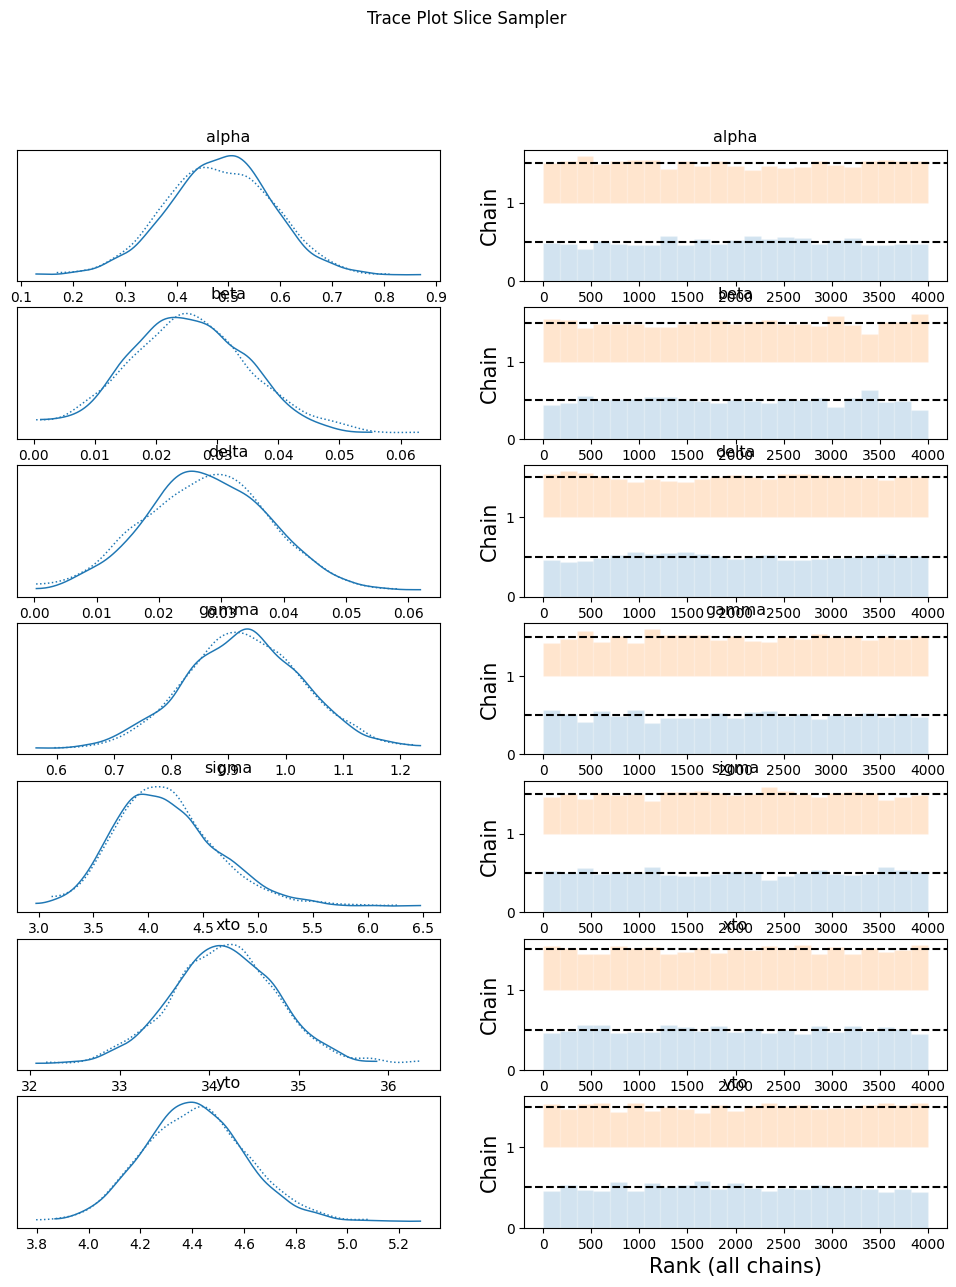

In [ ]:
az.plot_trace(trace, kind="rank_bars")
plt.suptitle(f"Trace Plot {sampler}");

ValueError: x and y must have same first dimension, but have shapes (2100,) and (21,)

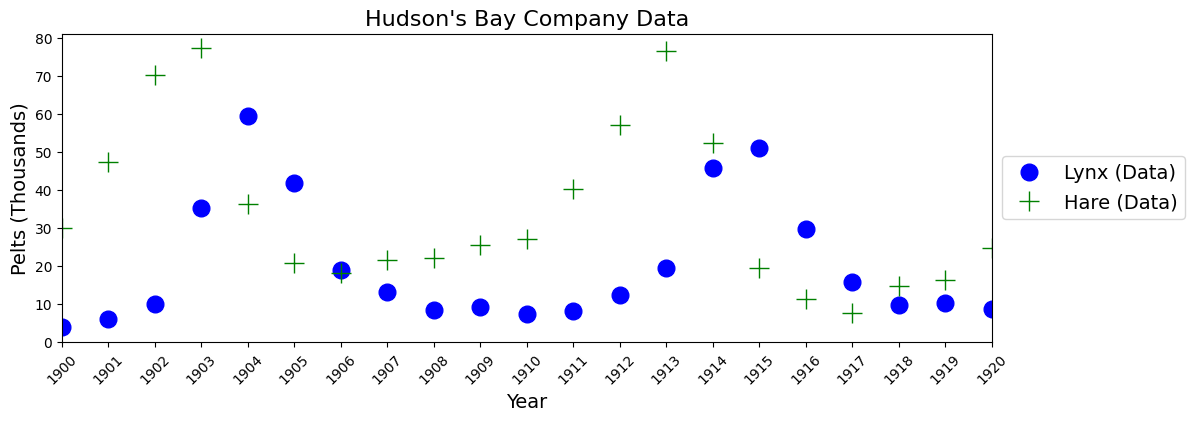

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_inference(ax, trace, title=f"Data and Inference Model Runs\n{sampler} Sampler");

## GLV 3-Species Bayesian Coupling Param Estimation

### Simulate 3-Species data

Recall that

$$\begin{aligned}
  \dot{z}
  &= \begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix} \\
  &= \begin{bmatrix} x \\ y \end{bmatrix}\odot \begin{bmatrix} \alpha - \beta y \\ -\gamma + \delta x \end{bmatrix} \\
  &= \begin{bmatrix} x & 0 \\ 0 & y \end{bmatrix} \left ( \begin{bmatrix} \alpha \\ -\gamma \end{bmatrix} + \begin{bmatrix} -\beta y \\ \delta x \end{bmatrix} \right ) \\
  &= \begin{bmatrix} x & 0 \\ 0 & y \end{bmatrix} \left ( \begin{bmatrix} \alpha \\ -\gamma \end{bmatrix} + \begin{bmatrix} 0 & -\beta \\ \delta & 0 \end{bmatrix}\begin{bmatrix} x \\ y \end{bmatrix} \right ) \\
  &= D(z) \left ( r + A z\right ) \\
\end{aligned}$$

where

1. $x(t) \in \mathbb{R}^{n \times 1}$ is a column vector of $n$ species
2. $D(x(t))$ transforms the column vector into a diagonal $n \times n$ matrix,
3. $A \in \mathbb{R}^{n \times n}$ is an $n \times n$ vector of interactions amongst the $n$ species' populations,
4. $r \in \mathbb{R}^{n \times 1}$ is an $n$-dimensional column vector of intrinsic growth rates (or death rates if negative) for each species $i$, $i = 1, ..., n$.

Extending this to any arbitrary $n > 0$, in this sub-section $n = 3$, would mean that we need to choose $z, r \in \mathbb{R}^{n}$ and $A \in \mathbb{R}^{n \times n}$ to simulate, and later try to recover using teh Bayesian Inference method.

In [ ]:
# define the right hand side of the ODE equations in the Scipy odeint signature
from numba import njit

@njit
def gLV(X, t, r, A):
    return X * (r + A @ X)

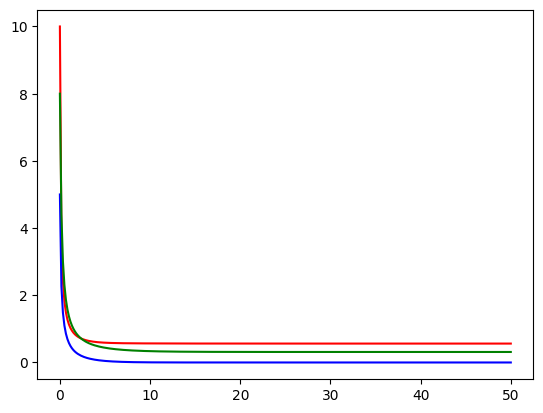

In [ ]:
rsim = np.array([0.5, -0.3, 0.2])  # Growth rates
Asim = np.array([
    [-1.0, -0.5,  0.2],  # Species 1 competes with 2, benefits from 3
    [-0.5, -1.0,  0.3],  # Species 2 competes with 1, benefits from 3
    [ 0.2,  0.3, -1.0]   # Species 3 benefits both but has self-limiting growth
])
X0 = np.array([10, 5, 8])  # Initial populations
# Time span
t_span = (0, 50)  # Simulate from t=0 to t=50
time = np.linspace(t_span[0], t_span[1], 300)  # Time points for evaluation

# Asim = np.array([[0., -0.08], [0.08, 0]])
# rsim = np.array([0.52, -0.84])
# X0 = np.array([34., 5.])
# time = np.arange(1900, 1921, 0.01)

x_y = odeint(func=gLV, y0=X0,
             t=time,
             args=(rsim, Asim,))

a = x_y[:, 0]
b = x_y[:, 1]
c = x_y[:, 2]

plt.plot(time, a, 'r') # plotting t, a separately
plt.plot(time, b, 'b') # plotting t, b separately
plt.plot(time, c, 'g') # plotting t, c separately
plt.show()

# # note theta = alpha, beta, gamma, delta, xt0, yt0
# alpha = 0.52
# beta = 0.026
# gamma = 0.84
# delta = 0.026
# xt0 = 34.0
# yt0 = 5.9
# theta = np.array([alpha, beta, gamma, delta, xt0, yt0])
# time = np.arange(1900, 1921, 0.01)

# # gLV params
# r = np.array([alpha, -gamma])
# A = np.array([[0, -beta], [delta, 0]])

# # call Scipy's odeint function
# # y0 is the X in the gLV formal parameter list,
# # t is the t in the gLV formal parameter list,
# #   which isnt really used in the suite of the gLV (or rhs)
# #   function itself
# x_y = odeint(func=gLV, y0=theta[-2:],
#              t=time,
#              args=(r, A,))

In [ ]:
a.shape

(2100,)

## GLV 4-Species Bayesian Coupling Param Estimation

### Simulate 4-GLV Data

In [ ]:
from numba import njit

@njit
def gLV(X, t, r, A):
    return X * (r + A @ X)

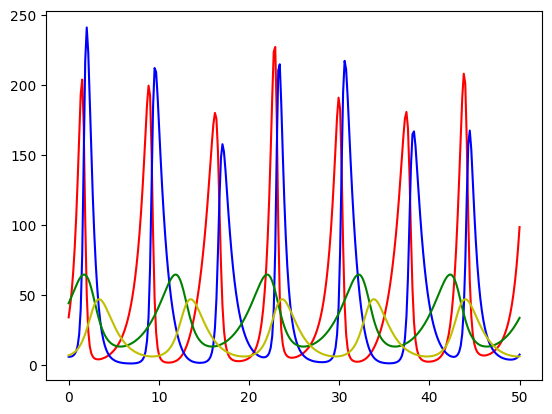

In [ ]:
rsim = np.array([0.52, -0.84, 0.52, -0.84])  # Growth rates

Asim = np.array([
    [0., -0.026, 0.02, 0.],
    [0.026, 0., 0., -0.02],
    [0., 0., 0., -0.026],
    [0., 0., 0.026, 0.]
])

# Asim = np.array([
#     [-1.0, -0.5,  0.2],  # Species 1 competes with 2, benefits from 3
#     [-0.5, -1.0,  0.3],  # Species 2 competes with 1, benefits from 3
#     [ 0.2,  0.3, -1.0]   # Species 3 benefits both but has self-limiting growth
# ])
X0 = np.array([34.0, 5.9, 44.0, 6.9])  # Initial populations
# Time span
t_span = (0, 50)  # Simulate from t=0 to t=50
time = np.linspace(t_span[0], t_span[1], 300)  # Time points for evaluation

# Asim = np.array([[0., -0.08], [0.08, 0]])
# rsim = np.array([0.52, -0.84])
# X0 = np.array([34., 5.])
# time = np.arange(1900, 1921, 0.01)

data_4glv = odeint(func=gLV, y0=X0,
             t=time,
             args=(rsim, Asim,))
data_4glv_noise = data_4glv + np.random.normal(scale=0.01,
                                               size=data_4glv.shape)

a = data_4glv_noise[:, 0]
b = data_4glv_noise[:, 1]
c = data_4glv_noise[:, 2]
d = data_4glv_noise[:, 3]

df_4glv = pd.DataFrame(data_4glv,
                       columns=["hare", "lynx", "fox", "wolf"])
df_4glv_noise = pd.DataFrame(data_4glv_noise,
                             columns=["hare", "lynx", "fox", "wolf"])

plt.plot(time, a, 'r') # plotting t, a separately
plt.plot(time, b, 'b') # plotting t, b separately
plt.plot(time, c, 'g') # plotting t, c separately
plt.plot(time, d, 'y') # plotting t, d separately
plt.show()

# # note theta = alpha, beta, gamma, delta, xt0, yt0
# alpha = 0.52
# beta = 0.026
# gamma = 0.84
# delta = 0.026
# xt0 = 34.0
# yt0 = 5.9
# theta = np.array([alpha, beta, gamma, delta, xt0, yt0])
# time = np.arange(1900, 1921, 0.01)

# # gLV params
# r = np.array([alpha, -gamma])
# A = np.array([[0, -beta], [delta, 0]])

# # call Scipy's odeint function
# # y0 is the X in the gLV formal parameter list,
# # t is the t in the gLV formal parameter list,
# #   which isnt really used in the suite of the gLV (or rhs)
# #   function itself
# x_y = odeint(func=gLV, y0=theta[-2:],
#              t=time,
#              args=(r, A,))

### 4-GLV Least Squares Param Estimation

In [ ]:
# function that calculates residuals based on a given theta

def ode_resid_flatten(X0, r, A):

    """
    Takes the X0 (n, 1), r (n, 1), A (n, n) and flattens and
    concatenates into one array of size (n + n + n * n)
    """
    params = np.concatenate((X0, rsim, Asim.flatten()))
    return params

def ode_resid_unflatten(params, n = 4):
    """
    Reverses ode_resid_flatten from flattened to X0, r, A
    """

    X0 = params[:n]
    r = params[n:2*n]
    A = params[2*n:].reshape((n, n))

    return X0, r, A


def ode_model_resid(params):
    """
    params : flattened vector of X0, r, and A.
    returns : flattened vector of residuals after applying least squares
    """
    X0, r, A = ode_resid_unflatten(params, 4)
    # theta = np.concatenate((X0, r
    # y0 = theta[-2:]
    # r = np.array([theta[0], -theta[2]])
    # A = np.array([[0, -theta[1]], [theta[3], 0]])

    sol = odeint(func=gLV, y0=X0,
             t=time,
             args=(r, A,))

    return (
        df_4glv_noise[["hare", "lynx", "fox", "wolf"]] - sol
    ).values.flatten()

# calculate least squares using the Scipy solver
theta_4glv = ode_resid_flatten(X0, rsim, Asim)
results_glv4 = least_squares(ode_model_resid, x0=theta_4glv)
X0_est, r_est, A_est = ode_resid_unflatten(params = results_glv4.x,
                                           n = X0.shape[0])

# df = pd.DataFrame()
# parameter_names =
# df["Parameter"] = parameter_names
# df["Least Squares Solution"] = results_glv2.x
# df.round(2)

# put the results in a dataframe for presentation and convenience
# df = pd.DataFrame()
# parameter_names = ["alpha", "beta", "gamma", "delta", "h0", "l0"]
# df["Parameter"] = parameter_names
# df["Least Squares Solution"] = results_glv2.x
# df.round(2)

In [ ]:
X0_est

array([34. ,  5.9, 44. ,  6.9])

In [ ]:
r_est

array([ 0.52, -0.84,  0.52, -0.84])

In [ ]:
A_est

array([[ 0.   , -0.026,  0.02 ,  0.   ],
       [ 0.026,  0.   ,  0.   , -0.02 ],
       [ 0.   ,  0.   ,  0.   , -0.026],
       [ 0.   ,  0.   ,  0.026,  0.   ]])

### 4-GLV Bayesian Param Estimation

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0, r, A = ode_resid_unflatten(theta, 4)

    return odeint(func=gLV, y0=X0,
                  t=time,
                  args=(rsim, Asim,))


In [ ]:
Asim

array([[ 0.   , -0.026,  0.02 ,  0.   ],
       [ 0.026,  0.   ,  0.   , -0.02 ],
       [ 0.   ,  0.   ,  0.   , -0.026],
       [ 0.   ,  0.   ,  0.026,  0.   ]])

In [ ]:
theta_glv4 = results_glv4.x  # least squares solution used to inform the priors
n = len(X0)
with pm.Model() as model:

    priors = []

    # Params for X0
    for i in range(n):

      prior = pm.Normal(f"x{i}",
                                mu=X0[i],
                                sigma=0.1,
                                initval=X0[i])
      priors.append(prior)

    # Params for r
    for i in range(n):
      prior = pm.Normal(f"r{i}",
                                mu=rsim[i],
                                sigma=0.1,
                                initval=rsim[i])
      priors.append(prior)


    # Params for A
    for k in range(n * n):
      # row and column indexes
      i, j = k // n, k % n

      prior = pm.Normal(f"A({i}, {j})",
                                mu=Asim[i, j],
                                sigma=0.1,
                                initval=Asim[i, j])
      priors.append(prior)

    # # Priors
    # alpha = pm.TruncatedNormal("alpha", mu=theta_glv2[0], sigma=0.1, lower=0, initval=theta_glv2[0])
    # beta = pm.TruncatedNormal("beta", mu=theta_glv2[1], sigma=0.01, lower=0, initval=theta_glv2[1])
    # gamma = pm.TruncatedNormal("gamma", mu=theta_glv2[2], sigma=0.1, lower=0, initval=theta_glv2[2])
    # delta = pm.TruncatedNormal("delta", mu=theta_glv2[3], sigma=0.01, lower=0, initval=theta_glv2[3])
    # xt0 = pm.TruncatedNormal("xto", mu=theta_glv2[4], sigma=1, lower=0, initval=theta_glv2[4])
    # yt0 = pm.TruncatedNormal("yto", mu=theta_glv2[5], sigma=1, lower=0, initval=theta_glv2[5])
    sigma = pm.HalfNormal("sigma", 2)



    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=df_4glv[["hare", "lynx", "fox", "wolf"]].values)

### 4-GLV Graph

In [ ]:
Asim

array([[ 0.   , -0.026,  0.02 ,  0.   ],
       [ 0.026,  0.   ,  0.   , -0.02 ],
       [ 0.   ,  0.   ,  0.   , -0.026],
       [ 0.   ,  0.   ,  0.026,  0.   ]])

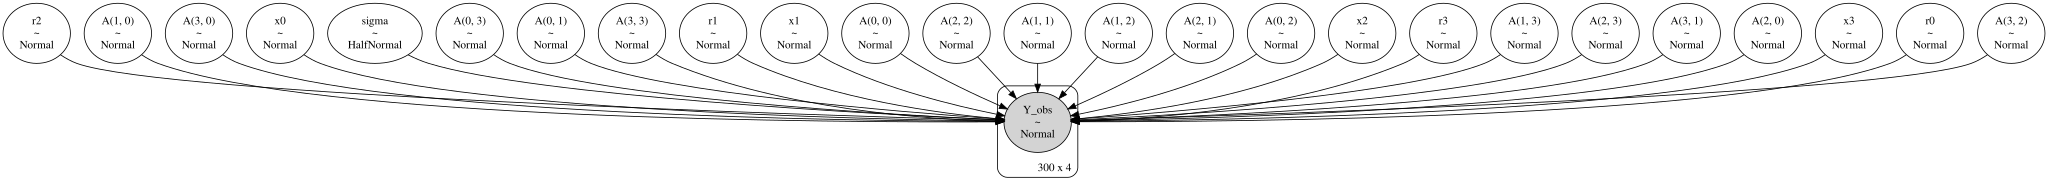

In [ ]:
pm.model_to_graphviz(model=model)

### Bayesian Inference

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

vars_list

[x0,
 x1,
 x2,
 x3,
 r0,
 r1,
 r2,
 r3,
 A(0, 0),
 A(0, 1),
 A(0, 2),
 A(0, 3),
 A(1, 0),
 A(1, 1),
 A(1, 2),
 A(1, 3),
 A(2, 0),
 A(2, 1),
 A(2, 2),
 A(2, 3),
 A(3, 0),
 A(3, 1),
 A(3, 2),
 A(3, 3),
 sigma_log__]

In [ ]:
?pm.sample

**NOTE: BELOW STEP TOOK 3 Hours!**


In [ ]:
# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 1000

# Inference!
with model:
    trace_slice = pm.sample(tune=tune,
                            step=[pm.Slice(vars_list)],
                            draws=draws,
                            nuts_sampler = "pymc")

trace = trace_slice
az.summary(trace)

 Progress                           Draws   Tuning   Steps out   Steps in   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000    False    0           9          1.81 s/draws     1:00:13   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000    False    0           6          3.55 s/draws     1:58:09   0:00:00

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"A(0, 0)",0.001,0.100,-0.178,0.202,0.002,0.002,2028.0,1250.0,1.00
"A(0, 1)",-0.022,0.100,-0.219,0.154,0.002,0.002,1802.0,1422.0,1.00
"A(0, 2)",0.023,0.103,-0.168,0.212,0.002,0.002,2025.0,1300.0,1.00
"A(0, 3)",0.000,0.102,-0.183,0.193,0.002,0.002,2098.0,1314.0,1.00
"A(1, 0)",0.027,0.100,-0.143,0.219,0.002,0.002,2093.0,1428.0,1.00
"A(1, 1)",-0.001,0.101,-0.197,0.187,0.002,0.002,1914.0,1308.0,1.00
"A(1, 2)",0.002,0.101,-0.189,0.195,0.002,0.002,1916.0,1370.0,1.00
"A(1, 3)",-0.026,0.101,-0.210,0.160,0.002,0.002,1713.0,1356.0,1.00
"A(2, 0)",0.002,0.104,-0.186,0.202,0.002,0.003,2006.0,920.0,1.00
"A(2, 1)",0.004,0.096,-0.194,0.174,0.002,0.002,1952.0,1412.0,1.00


In [ ]:
az.summary(trace).to_csv("results_3_13_2025_4glv_pymc.csv")

In [ ]:
df_est_4glv_3_13 = az.summary(trace)

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
df_est_4glv_3_13['mean']['A(0, 0)']

A_est = np.empty((n, n))

for i in range(n):
  for j in range(n):
    A_est[i, j] = df_est_4glv_3_13['mean'][f'A({i}, {j})']

A_est

array([[ 0.001, -0.022,  0.023,  0.   ],
       [ 0.027, -0.001,  0.002, -0.026],
       [ 0.002,  0.004, -0.003, -0.026],
       [ 0.002,  0.   ,  0.026, -0.001]])

In [ ]:
Asim

array([[ 0.   , -0.026,  0.02 ,  0.   ],
       [ 0.026,  0.   ,  0.   , -0.02 ],
       [ 0.   ,  0.   ,  0.   , -0.026],
       [ 0.   ,  0.   ,  0.026,  0.   ]])

### Plot Posterior Estimates

/usr/local/lib/python3.11/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (25), generating only 20 plots
  warnings.warn(


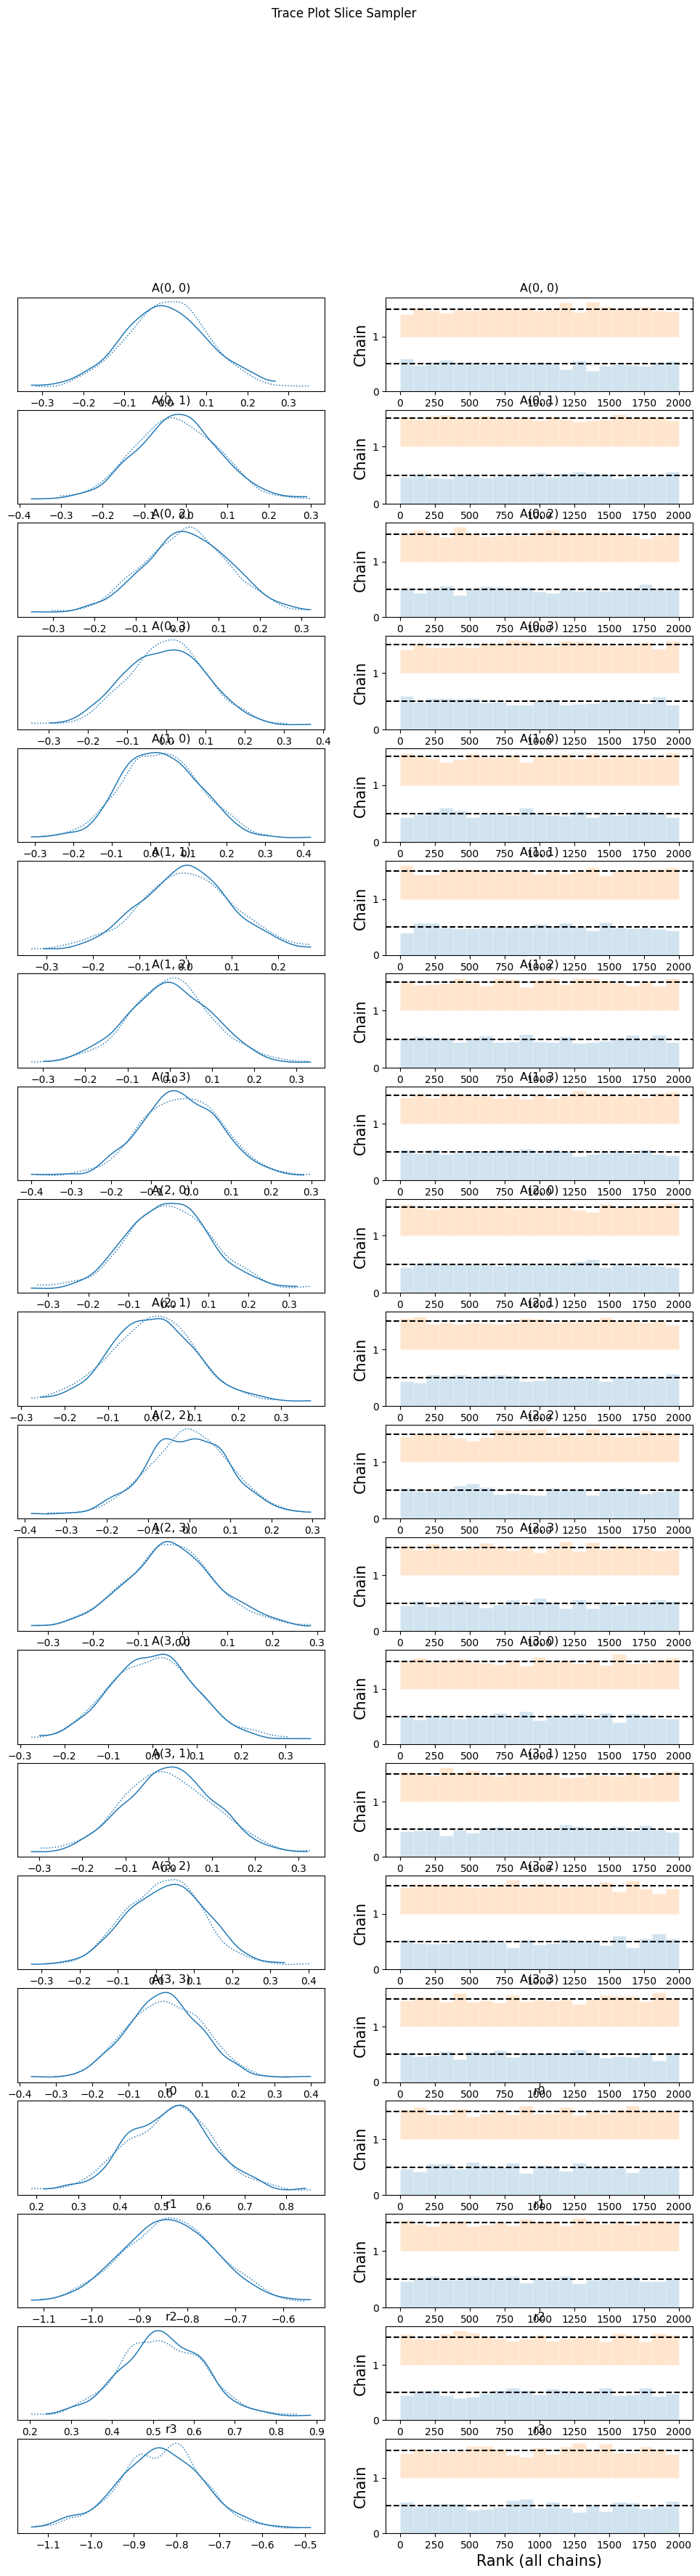

In [ ]:
az.plot_trace(trace, kind="rank_bars")
plt.suptitle(f"Trace Plot {sampler}");

# Dinner

## Import Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/data/"
dinner_path = os.path.join(data_path, "dinner/")

dinner_df = pd.read_csv(os.path.join(dinner_path, "dinner_dataset.csv"))
dinner_df = dinner_df.rename(columns={'Time (hours)':'time'})

dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


Text(0.5, 1.0, 'Cyanobacterial In-Vitro Clock Oscillator Concentrations')

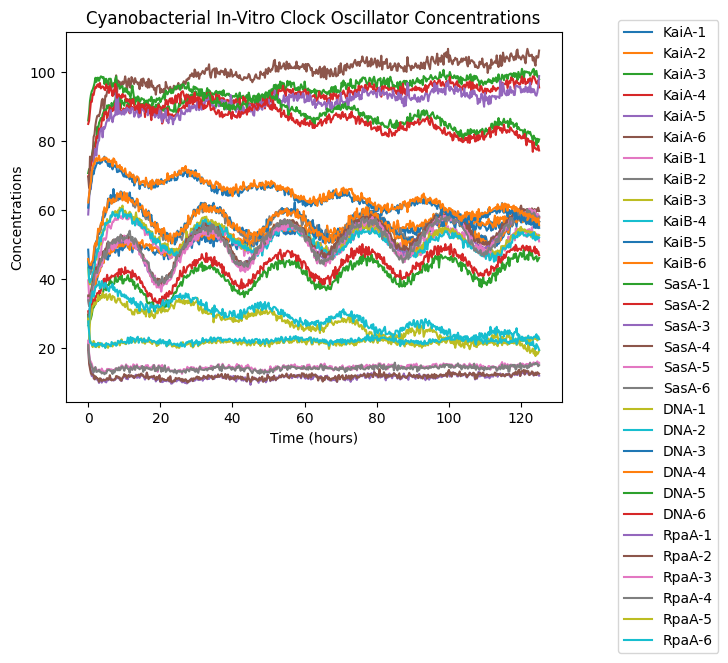

In [ ]:
ax = dinner_df.plot(x = 'time')

ax.legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel('Time (hours)')
plt.ylabel("Concentrations")
plt.title('Cyanobacterial In-Vitro Clock Oscillator Concentrations')


## Sample Data

<Axes: xlabel='time'>

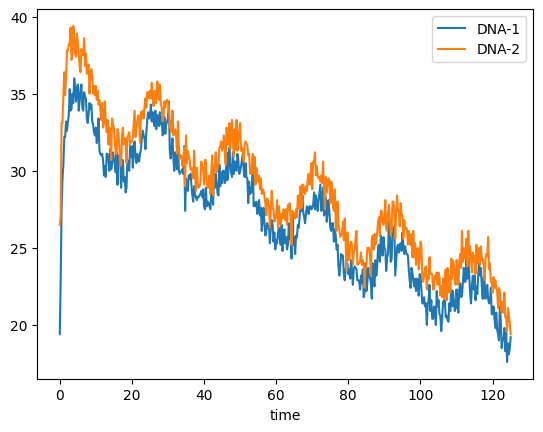

In [ ]:
dna12_df = dinner_df[['time', 'DNA-1', 'DNA-2']]

dna12_df.plot(x = 'time')

## Remove Trend

<Axes: xlabel='time'>

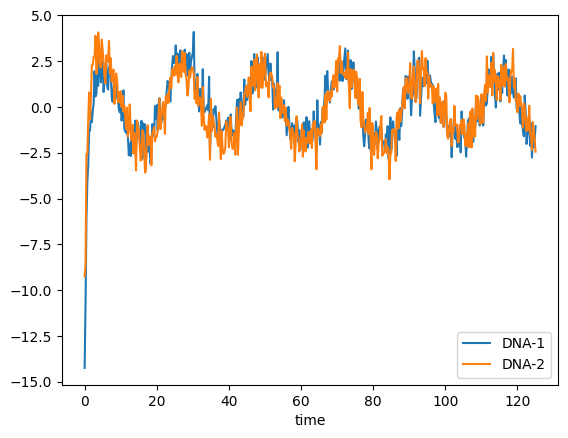

In [ ]:
dna12_det = dna12_df.copy()
dna12_det['DNA-1'] = detrend(dna12_det['DNA-1'])
dna12_det['DNA-2'] = detrend(dna12_det['DNA-2'])

dna12_det.plot(x = 'time')

## Solve Least Squares Dinner (DNA-1 &2)

**Edit: Per Tom's recommendation, since it is difficult to visually assess which two gene transcripts are coupled, just model all of them together, which we will attempt in the next subsection.**

In [ ]:
# note theta = alpha, beta, gamma, delta, xt0, yt0
alpha = 0.52
beta = 0.026
gamma = 0.84
delta = 0.026
xt0 = -13.0
yt0 = -8.9

r_dna12_sim = np.array([alpha, -gamma])
A_dna12_sim = np.array([[0, -beta], [delta, 0]])
X0_dna12_sim = np.array([xt0, yt0])

# theta = np.array([alpha, beta, gamma, delta, xt0, yt0])
time = dna12_det['time'].values

In [ ]:
from numba import njit

@njit
def gLV(X, t, r, A):
    return X * (r + A @ X)

def ode_resid_flatten(X0, r, A):

    """
    Takes the X0 (n, 1), r (n, 1), A (n, n) and flattens and
    concatenates
     into one array of size (n + n + n * n)

    Function that calculates residuals based on a given theta
    """
    params = np.concatenate((X0, r, A.flatten()))
    return params

def ode_resid_unflatten(params, n = 2):
    """
    Reverses ode_resid_flatten from flattened to X0, r, A
    """

    X0 = params[:n]
    r = params[n:2*n]
    A = params[2*n:].reshape((n, n))

    return X0, r, A


def ode_model_resid(params):
    """
    params : flattened vector of X0, r, and A.
    returns : flattened vector of residuals after applying least squares
    """
    X0, r, A = ode_resid_unflatten(params, 2)
    # theta = np.concatenate((X0, r
    # y0 = theta[-2:]
    # r = np.array([theta[0], -theta[2]])
    # A = np.array([[0, -theta[1]], [theta[3], 0]])

    sol = odeint(func=gLV,
                 y0=X0,
                 t=time,
                 args=(r, A,))

    return (
        dna12_det[["DNA-1", "DNA-2"]] - sol
    ).values.flatten()

# calculate least squares using the Scipy solver
theta_dna12 = ode_resid_flatten(X0_dna12_sim,
                                r_dna12_sim,
                                A_dna12_sim)
results_dna12 = least_squares(ode_model_resid,
                              x0=theta_dna12)
dna12_lq = ode_resid_unflatten(params = results_dna12.x,
                               n = X0_dna12_sim.shape[0])
X0_dna12_lq, r_dna12_lq, A_dna12_lq = dna12_lq

# df = pd.DataFrame()
# parameter_names =
# df["Parameter"] = parameter_names
# df["Least Squares Solution"] = results_glv2.x
# df.round(2)

# put the results in a dataframe for presentation and convenience
# df = pd.DataFrame()
# parameter_names = ["alpha", "beta", "gamma", "delta", "h0", "l0"]
# df["Parameter"] = parameter_names
# df["Least Squares Solution"] = results_glv2.x
# df.round(2)

In [ ]:
def gLV(t, X, r, A):
    return X * (r + A @ X)

sol_dna12_ivp = solve_ivp(fun = gLV,
                          t_span = (time[0], time[-1]),
                          y0=X0_dna12_sim,
                          args=(r_dna12_sim, A_dna12_sim), t_eval=time)

In [ ]:


# plot data function for reuse later
def plot_data_dna12(
    ax,
    lw=2,
    title="DNA 1 & 2 Least Squares Estimate"
):
    ax.plot(dna12_det.time, dna12_det['DNA-1'], color="b", lw=lw, marker="o", markersize=12, label="True DNA-1")
    ax.plot(dna12_det.time, dna12_det['DNA-2'], color="g", lw=lw, marker="+", markersize=14, label="True DNA-2")
    ax.legend(fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    # ax.set_xlim([1900, 1920])
    # ax.set_ylim(0)
    ax.set_xlabel("Time (Hours)", fontsize=14)
    ax.set_ylabel("Concentration", fontsize=14)
    ax.set_xticks(dna12_det.time.astype(int))
    ax.set_xticklabels(ax.get_xticks(), rotation=45)
    ax.set_title(title, fontsize=16)
    return ax

 # plot model function
def plot_model_dna12(
    ax,
    x_y,
    time=dna12_df.time,
    alpha=1,
    lw=3,
    title="DNA 1 & 2 Least Squares Estimates",
):
    ax.plot(time, x_y[:, 0], color="r", alpha=alpha, lw=lw, label="Predicted DNA-1")
    ax.plot(time, x_y[:, 1], color="c", alpha=alpha, lw=lw, label="Predicted DNA-2")
    ax.legend(fontsize=14, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, fontsize=16)
    return ax

In [ ]:
X0_dna12_lq

array([-13. ,  -8.9])

In [ ]:
A_dna12_lq

array([[ 1.49011612e-08, -2.60000000e-02],
       [ 2.60000000e-02,  1.18342389e-16]])

In [ ]:
results_dna12.x

array([ -1.96430497,   5.18780382,   1.48083187,  15.3871151 ,
         9.49088501,  27.15646454, -14.24079181,  -9.24490947])

In [ ]:
# function that calculates residuals based on a given theta
def ode_dinner_model_resid(theta):

    y0 = theta[-2:]
    r = np.array([theta[0], theta[2]])
    A = np.array([[0, theta[1]], [theta[3], 0]])

    sol = odeint(func=gLV, y0=theta[-2:],
             t=dna12_det.time,
             args=(r, A,))

    return (
        dna12_det[["DNA-1", "DNA-2"]] - sol
    ).values.flatten()

# calculate least squares using the Scipy solver
theta_dna12_lq = ode_resid_flatten(X0_dna12_lq,
                                   r_dna12_lq,
                                   A_dna12_lq)

results_dna12 = least_squares(ode_dinner_model_resid, x0=theta_dna12_lq)

# put the results in a dataframe for presentation and convenience
dna12_sol_df = pd.DataFrame()
parameter_names = ["X0_DNA1", "X0_DNA2", "r_DNA1", "r_DNA2",
                   "A_11", "A_12", "A_21", "A_22"]
dna12_sol_df["Parameter"] = parameter_names
dna12_sol_df["Least Squares Solution"] = results_dna12.x
dna12_sol_df.round(2)

<ipython-input-37-43dc8d496881>:8: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1 to get quantitative information.
  sol = odeint(func=gLV, y0=theta[-2:],
<ipython-input-37-43dc8d496881>:8: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(func=gLV, y0=theta[-2:],


,Parameter,Least Squares Solution
0,X0_DNA1,-1.42
1,X0_DNA2,30.54
2,r_DNA1,-3.52
3,r_DNA2,-22.92
4,A_11,-0.00
5,A_12,8.90
6,A_21,-14.27
7,A_22,-9.29


In [ ]:
results_dna12.x[2:4]

array([ -3.520348  , -22.92194377])

In [ ]:
ode_resid_unflatten(results_dna12.x)

(array([-1.42059586, 30.54254964]),
 array([ -3.520348  , -22.92194377]),
 array([[-3.74183663e-10,  8.89742557e+00],
        [-1.42741443e+01, -9.28886706e+00]]))

<ipython-input-55-992a0f6b2df0>:7: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  dna12_least_sq = odeint(func=gLV, y0=X0_dna12_lq,


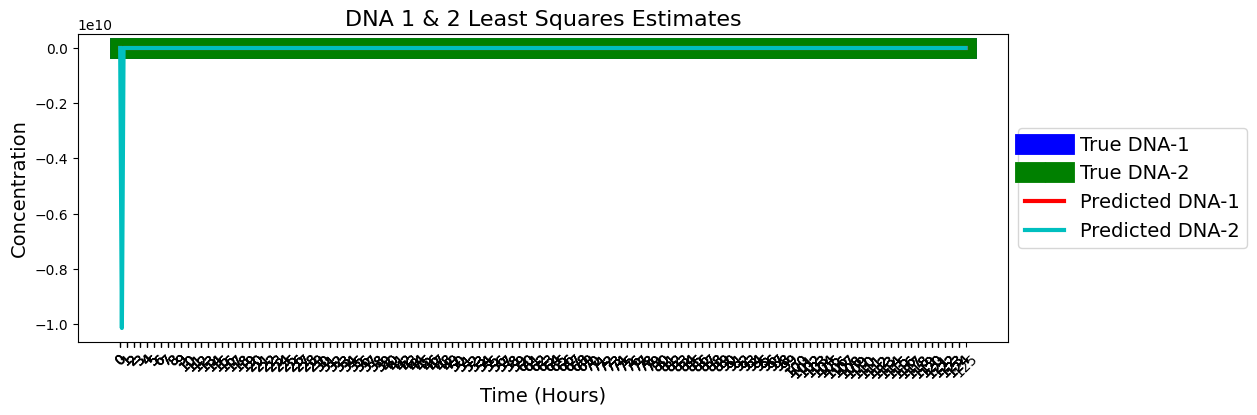

In [ ]:
X_dna12_lq = results_dna12.x[0:2]
r_dna12_lq = results_dna12.x[2:4] # np.array([results_dna12.x[0], results_dna12.x[2]])
A_dna12_lq = results_dna12.x[4:]  # np.array([[0, results_dna12.x[1]], [results_dna12.x[3], 0]])

X_dna12_lq, r_dna12_lq, A_dna12_lq = ode_resid_unflatten(results_dna12.x)

dna12_least_sq = odeint(func=gLV, y0=X0_dna12_lq,
                        t=time,
                        args=(r_dna12_lq, A_dna12_lq,))

# plot
_, ax = plt.subplots(figsize=(12, 4))
plot_data_dna12(ax, lw=-15)
plot_model_dna12(ax, dna12_least_sq);

## Dinner (DNA-1 & 2) Bayesian Inference

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0, r, A = ode_resid_unflatten(theta, 4)

    return odeint(func=gLV, y0=X0,
                  t=time,
                  args=(rsim, Asim,))


### Set up priors

In [ ]:
theta_glv_dna12 = results_dna12.x  # least squares solution used to inform the priors
X_dna12_lq, r_dna12_lq, A_dna12_lq = ode_resid_unflatten(results_dna12.x)

n = len(X_dna12_lq)
with pm.Model() as model:

    priors = []

    # Params for X0
    for i in range(n):

      prior = pm.Normal(f"x{i}",
                                mu=X_dna12_lq[i],
                                sigma=0.1,
                                initval=X_dna12_lq[i])
      priors.append(prior)

    # Params for r
    for i in range(n):
      prior = pm.Normal(f"r{i}",
                                mu=r_dna12_lq[i],
                                sigma=0.1,
                                initval=r_dna12_lq[i])
      priors.append(prior)


    # Params for A
    for k in range(n * n):
      # row and column indexes
      i, j = k // n, k % n

      prior = pm.Normal(f"A({i}, {j})",
                                mu=A_dna12_lq[i, j],
                                sigma=0.1,
                                initval=A_dna12_lq[i, j])
      priors.append(prior)

    # # Priors
    # alpha = pm.TruncatedNormal("alpha", mu=theta_glv2[0], sigma=0.1, lower=0, initval=theta_glv2[0])
    # beta = pm.TruncatedNormal("beta", mu=theta_glv2[1], sigma=0.01, lower=0, initval=theta_glv2[1])
    # gamma = pm.TruncatedNormal("gamma", mu=theta_glv2[2], sigma=0.1, lower=0, initval=theta_glv2[2])
    # delta = pm.TruncatedNormal("delta", mu=theta_glv2[3], sigma=0.01, lower=0, initval=theta_glv2[3])
    # xt0 = pm.TruncatedNormal("xto", mu=theta_glv2[4], sigma=1, lower=0, initval=theta_glv2[4])
    # yt0 = pm.TruncatedNormal("yto", mu=theta_glv2[5], sigma=1, lower=0, initval=theta_glv2[5])
    sigma = pm.HalfNormal("sigma", 2)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=dna12_det[["DNA-1", "DNA-2"]].values)

### Graph Priors

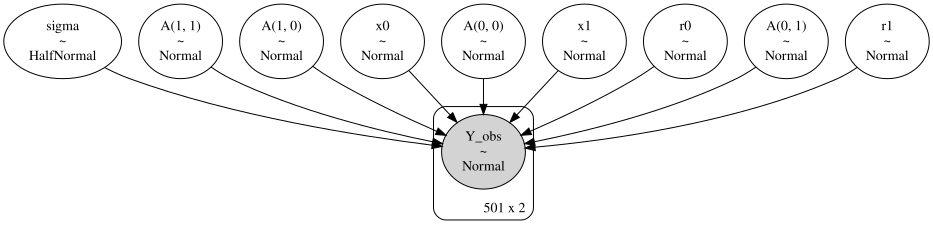

In [ ]:
pm.model_to_graphviz(model=model)

### Dinner DNA-1&2 Sampling

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

vars_list

[x0, x1, r0, r1, A(0, 0), A(0, 1), A(1, 0), A(1, 1), sigma_log__]

In [ ]:
# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 1000

# Inference!
with model:
    trace_slice = pm.sample(tune=tune,
                            step=[pm.Slice(vars_list)],
                            draws=draws,
                            nuts_sampler = "pymc")

trace = trace_slice
az.summary(trace)

Output()

ValueError: cannot reshape array of size 0 into shape (4,4)
Apply node that caused the error: FromFunctionOp{pytensor_forward_model_matrix}(MakeVector{dtype='float64'}.0)
Toposort index: 6
Inputs types: [TensorType(float64, shape=(8,))]
Inputs shapes: [(8,)]
Inputs strides: [(8,)]
Inputs values: ['not shown']
Outputs clients: [[Composite{switch(i4, ((-0.9189385332046727 + (-0.5 * sqr(((i0 - i1) / i2)))) - i3), -inf)}(Y_obs{[[-14.2408 ... 43394963]]}, FromFunctionOp{pytensor_forward_model_matrix}.0, ExpandDims{axes=[0, 1]}.0, Log.0, Gt.0)]]

Backtrace when the node is created (use PyTensor flag traceback__limit=N to make it longer):
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/zmqshell.py", line 528, in run_cell
    return super().run_cell(*args, **kwargs)
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2975, in run_cell
    result = self._run_cell(
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", lin

## Least Squares on all Dinner waveforms

In [ ]:
t_y = pt.vector("y", dtype="float64")
t_y.tag.test_value = np.ones((30,), dtype="float64")
t_y.tag.test_value

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


In [ ]:
dinner_wo_time.describe()

,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,KaiB-4,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,...,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,52.360479,53.407186,94.601397,92.749102,90.999601,99.945309,51.390220,56.051297,52.180439,51.328743,...,64.021956,64.870659,89.099002,86.826347,11.485431,11.703615,14.417352,14.075889,21.602951,22.080535
std,4.127866,4.428032,4.253932,4.044763,4.243904,4.671030,3.743389,3.835500,3.590807,3.457099,...,4.581100,4.491249,4.514959,4.266331,0.877689,0.828634,0.737431,0.714284,0.725524,0.724864
min,28.400000,27.300000,70.700000,69.800000,58.700000,66.400000,35.100000,41.400000,38.400000,39.000000,...,54.800000,55.700000,78.800000,76.900000,9.256574,9.935664,12.457261,12.339079,19.663518,19.971433
25%,50.300000,51.100000,92.600000,90.800000,89.400000,98.300000,48.700000,52.900000,49.400000,48.600000,...,60.400000,61.200000,85.400000,83.500000,10.953353,11.188026,13.996636,13.664567,21.184586,21.661038
50%,53.100000,54.400000,95.100000,93.500000,91.700000,101.000000,51.800000,56.300000,52.200000,51.500000,...,63.700000,64.600000,89.100000,86.700000,11.479166,11.698307,14.396730,14.091165,21.577303,22.099731
75%,55.200000,56.400000,97.700000,95.500000,93.500000,102.600000,54.200000,58.900000,54.800000,53.700000,...,67.200000,68.000000,92.500000,89.900000,11.982974,12.143287,14.821642,14.466055,22.043253,22.504782
max,58.400000,60.700000,101.000000,98.800000,98.900000,106.800000,58.900000,65.300000,61.300000,60.300000,...,75.500000,75.800000,98.800000,96.900000,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978


In [ ]:
dinner_sampled = dinner_df
dinner_wo_time = dinner_sampled.drop(columns = ['time'], inplace = False)
n_waves = dinner_wo_time.shape[1]

np.random.seed(42)  # For reproducibility

# Initial populations
X0_din_sim = np.random.uniform(5, 15, n_waves) # np.random.normal(28, 75, size = n_waves).astype(np.float64)

# Randomized growth rates (ensuring moderate values)
r_din_sim = np.random.normal(0.1, 0.5, size = (n_waves)).astype(np.float64)

# Random interaction matrix with self-limiting diagonal
A_din_sim = np.random.normal(-0.5, 0.5, size = (n_waves, n_waves)).astype(np.float64)
np.fill_diagonal(A_din_sim, -1)

time = dinner_sampled['time'].values
t_span_din = (int(time[0]), int(time[-1]))
t_eval_din = np.linspace(*t_span_din, 500)

In [ ]:
def gLV(t, X, r, A):
    return X * (r + np.matmul(A, X))

In [ ]:
# din_ivp_sol = solve_ivp(fun    = gLV,
#                         t_span = t_span_din,
#                         y0     = X0_din_sim,
#                         args   = (r_din_sim, A_din_sim),
#                         t_eval = t_eval_din,
#                         method = 'LSODA',
#                         # method = 'Radau',
#                         # dense_output = True
#                         )

# # sol = solve_ivp(lotka_volterra, t_span, X0, t_eval=t_eval, args=(r, A))

In [ ]:
# din_ode_sol = odeint(func = gLV, y0 = X0_din_sim, t = time, args = (r_din_sim, A_din_sim,))

In [ ]:
def gLV(t, X, r, A):
    return X * (r + A @ X)

def ode_resid_flatten(X0, r, A):

    """
    Takes the X0 (n, 1), r (n, 1), A (n, n) and flattens and
    concatenates
     into one array of size (n + n + n * n)

    Function that calculates residuals based on a given theta
    """

    params = np.concatenate((X0, r, A.flatten()))
    return params

def ode_resid_unflatten(params, n = 2):
    """
    Reverses ode_resid_flatten from flattened to X0, r, A
    """

    X0 = params[:n]
    r = params[n:2*n]
    A = params[2*n:].reshape((n, n))

    return X0, r, A


def ode_model_resid(params):
    """
    params : flattened vector of X0, r, and A.
    returns : flattened vector of residuals after applying least squares
    """
    X0, r, A = ode_resid_unflatten(params, 30)

    sol = solve_ivp(fun    = gLV,
                    t_span = (time[0], time[-1]),
                    y0     = X0,
                    args   = (r, A),
                    t_eval = time,
                    method = 'Radau',
                    dense_output = True).y

    # sol = odeint(func=gLV,
    #              y0=X0,
    #              t=time,
    #              args=(r, A,))

    return (
        dinner_wo_time.T.values - sol
    ).flatten()

# calculate least squares using the Scipy solver
theta_din_sim = ode_resid_flatten(X0 = X0_din_sim,
                                  r = r_din_sim,
                                  A = A_din_sim)

results_din_sim = least_squares(ode_model_resid,
                                x0=theta_din_sim)

din_lq = ode_resid_unflatten(params = results_din_sim.x,
                             n = n_waves)
X0_din_lq, r_din_lq, A_din_lq = din_lq

# df = pd.DataFrame()
# parameter_names =
# df["Parameter"] = parameter_names
# df["Least Squares Solution"] = results_glv2.x
# df.round(2)

# put the results in a dataframe for presentation and convenience
# df = pd.DataFrame()
# parameter_names = ["alpha", "beta", "gamma", "delta", "h0", "l0"]
# df["Parameter"] = parameter_names
# df["Least Squares Solution"] = results_glv2.x
# df.round(2)

KeyboardInterrupt: 

In [ ]:
traj_din_lq = solve_ivp(fun    = gLV,
                        t_span = (time[0], time[-1]),
                        y0     = X0_din_lq,
                        args   = (r_din_lq, A_din_lq),
                        t_eval = time,
                        method = 'LSODA',
                        # dense_output = True
                        )

<ipython-input-17-fab019527724>:2: RuntimeWarning: overflow encountered in multiply
  return X * (r + A @ X)
<ipython-input-17-fab019527724>:2: RuntimeWarning: invalid value encountered in multiply
  return X * (r + A @ X)
<ipython-input-17-fab019527724>:2: RuntimeWarning: invalid value encountered in matmul
  return X * (r + A @ X)
/usr/local/lib/python3.11/dist-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(


## Bayesian Inference on All Dinner Waveforms

### Helper Functions

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dvector], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0, r, A = theta

    return odeint(func=gLV, y0=X0,
                  t=time,
                  args=(rsim, Asim,))


### Graph Priors

In [ ]:
np.savetxt(os.path.join(dinner_path, "X0_din_lq.csv"),
           X0_din_lq,
           delimiter=",")

np.savetxt(os.path.join(dinner_path, "r_din_lq.csv"),
           r_din_lq,
           delimiter=",")

np.savetxt(os.path.join(dinner_path, "A_din_lq.csv"),
           A_din_lq,
           delimiter=",")

np.savetxt(os.path.join(dinner_path, "theta_din_lq.csv"),
           ode_resid_flatten(X0_din_lq, r_din_lq, A_din_lq),
           delimiter=",")

NameError: name 'X0_din_lq' is not defined

In [ ]:
X0_din_lq = np.loadtxt(os.path.join(dinner_path, "X0_din_lq.csv"),
                       delimiter=",")
r_din_lq = np.loadtxt(os.path.join(dinner_path, "r_din_lq.csv"),
                      delimiter=",")
A_din_lq = np.loadtxt(os.path.join(dinner_path, "A_din_lq.csv"),
                      delimiter=",")
theta_din_lq = np.loadtxt(os.path.join(dinner_path, "theta_din_lq.csv"),
                          delimiter=",")


time = dinner_sampled['time'].values
t_span_din = (int(time[0]), int(time[-1]))
t_eval_din = np.linspace(*t_span_din, 500)

In [ ]:
n = len(X0_din_lq)  # 30 time series
# p = (2 * n) + (n ** 2) # number of features since we have X (30, 1), r (30, 1), A (30, 30)
X0 = dinner_wo_time.iloc[0, :].values

# Solve ODE using the given parameters
def gLV(X, t, p):
  return X * p

# def solver(t, r, A):
#     sol = solve_ivp(gLV, t_span_din, X0, args=(r, A), t_eval=t)
#     return sol.y.T


# Use PyMC's ODE solver
diffeq = DifferentialEquation(
    func     = gLV,
    times    = time,
    n_states = n,            # Number of state variables
    n_theta  = 1,            # Number of parameters
    t0       = t_span_din[0]
)

with pm.Model() as model:
    # Priors for initial conditions (X0)
    X0_prior = pm.Normal(name = "X0_prior",
                         mu = X0_din_lq,
                         sigma = 0.1,
                         initval = X0,
                         shape = X0.shape)

    # Priors for growth rates (r)
    r0_prior = pm.Normal(name = "r0_prior",
                         mu = r_din_lq,
                         sigma = 0.1,
                         initval = r_din_lq,
                         shape = r_din_lq.shape)

    # Priors for interaction matrix (A)
    A_prior = pm.Normal(name = "A_prior",
                        mu = A_din_lq,
                        sigma = 0.1,
                        initval = A_din_lq,
                        shape = A_din_lq.shape)

    # Define the parameter for the ODE function as r + A @ X
    ode_params = pm.Potential("ode_params", r0_prior + A_prior @ X0_prior)

    # rAX_prior = pm.Normal(name = "rAX_prior",
    #                      mu = r0_prior + (A_prior @ X0_prior),
    #                      sigma = 0.000001,
    #                      initval = r_din_lq + A_din_lq @ X0,
    #                      shape = r_din_lq.shape
    #                      )

    ode_solution = diffeq(y0=X0_prior, theta=ode_params)

    # Likelihood function
    sigma = pm.HalfNormal("sigma", sigma=2)
    pm.Normal(
        "obs",
        mu=ode_solution,  # Use ode_solution directly
        sigma=sigma,
        observed=dinner_df.values,  # Use dinner_wo_time.values directly
    )

    # Sampling
    trace = pm.sample(1000, tune=1000, cores=2)

# # Summarize results
# az.summary(trace)



/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/shape.py:158: UserWarning: Failed to infer_shape from Op Sub.
Input shapes: [(TensorConstant(TensorType(int64, shape=()), data=array(501)), TensorConstant(TensorType(int64, shape=()), data=array(31))), (TensorConstant(TensorType(int64, shape=()), data=array(501)), TensorConstant(TensorType(int64, shape=()), data=array(30)))]
Exception encountered during infer_shape: <class 'ValueError'>
Exception message: Could not broadcast dimensions. Incompatible shapes were [(TensorConstant(TensorType(int64, shape=()), data=array(501)), TensorConstant(TensorType(int64, shape=()), data=array(31))), (TensorConstant(TensorType(int64, shape=()), data=array(501)), TensorConstant(TensorType(int64, shape=()), data=array(30)))].
Traceback: Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/shape.py", line 134, in get_node_infer_shape
    o_shapes = shape_infer(
               ^^^^^^^^

ValueError: could not broadcast input array from shape (30,31) into shape (30,60)
Apply node that caused the error: Gemm{inplace}(Scan{scan_fn&scan_fn, while_loop=False, inplace=none}.0, 1.0, Scan{scan_fn&scan_fn, while_loop=False, inplace=none}.1, Reshape{2}.0, 1.0)
Toposort index: 11
Inputs types: [TensorType(float64, shape=(None, None)), TensorType(float64, shape=()), TensorType(float64, shape=(None, None)), TensorType(float64, shape=(30, 31)), TensorType(float64, shape=())]
Inputs shapes: [(30, 60), (), (30, 30), (30, 31), ()]
Inputs strides: [(480, 8), (), (240, 8), (248, 8), ()]
Inputs values: ['not shown', array(1.), 'not shown', 'not shown', array(1.)]
Outputs clients: [[SpecifyShape(Gemm{inplace}.0, NoneConst{None}, 31)]]

HINT: Re-running with most PyTensor optimizations disabled could provide a back-trace showing when this node was created. This can be done by setting the PyTensor flag 'optimizer=fast_compile'. If that does not work, PyTensor optimizations can be disabled wi

In [ ]:
model.debug()

point={'X0_prior': array([28.4       , 27.3       , 70.7       , 69.8       , 58.7       ,
       69.6       , 39.6       , 45.7       , 43.3       , 45.        ,
       48.5       , 45.8       , 29.6       , 30.6       , 34.7       ,
       35.2       , 34.4       , 33.8       , 19.4       , 26.5       ,
       60.7       , 62.2       , 86.        , 85.        , 21.14619702,
       20.56198527, 22.07320804, 20.75957141, 28.4644881 , 27.6789776 ]), 'r0_prior': array([-19.82944455,  18.4560346 , -14.73067238,  47.86194911,
       -24.0442746 ,  29.6233032 ,  14.2464957 ,  -6.80415953,
        16.26885173,  -4.43397217,  12.69383649,  -9.88263982,
        -5.91519607,   6.85400255,  11.9972548 ,  12.83119816,
        13.14485329,  -8.99331012, -14.2620505 , -19.07333215,
       -11.22189253,  25.40949718,   6.75617631,  -9.90931839,
         5.58766799, -13.27041359,  -9.87730634, -14.17455077,
        15.10653436,  24.30597991]), 'A_prior': array([[-1.00351778e+01, -1.00808741e+01, -9.4

/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/shape.py:158: UserWarning: Failed to infer_shape from Op Sub.
Input shapes: [(TensorConstant(TensorType(int64, shape=()), data=array(501)), TensorConstant(TensorType(int64, shape=()), data=array(30))), (TensorConstant(TensorType(int64, shape=()), data=array(500)), TensorConstant(TensorType(int64, shape=()), data=array(30)))]
Exception encountered during infer_shape: <class 'ValueError'>
Exception message: Could not broadcast dimensions. Incompatible shapes were [(TensorConstant(TensorType(int64, shape=()), data=array(501)), TensorConstant(TensorType(int64, shape=()), data=array(30))), (TensorConstant(TensorType(int64, shape=()), data=array(500)), TensorConstant(TensorType(int64, shape=()), data=array(30)))].
Traceback: Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/shape.py", line 134, in get_node_infer_shape
    o_shapes = shape_infer(
               ^^^^^^^^

The variable obs has the following parameters:
0: DifferentialEquation{func=<function gLV at 0x797a025bdee0>, times=(0.0, 0.250501002004008, 0.501002004008016, 0.751503006012024, 1.002004008016032, 1.2525050100200399, 1.503006012024048, 1.753507014028056, 2.004008016032064, 2.254509018036072, 2.5050100200400798, 2.7555110220440877, 3.006012024048096, 3.256513026052104, 3.507014028056112, 3.75751503006012, 4.008016032064128, 4.258517034068136, 4.509018036072144, 4.759519038076152, 5.0100200400801596, 5.260521042084168, 5.511022044088175, 5.761523046092184, 6.012024048096192, 6.2625250501002, 6.513026052104208, 6.7635270541082155, 7.014028056112224, 7.264529058116231, 7.51503006012024, 7.765531062124247, 8.016032064128256, 8.266533066132263, 8.517034068136272, 8.76753507014028, 9.018036072144287, 9.268537074148295, 9.519038076152304, 9.769539078156312, 10.020040080160319, 10.270541082164328, 10.521042084168336, 10.771543086172343, 11.02204408817635, 11.27254509018036, 11.523046092184368,

/usr/local/lib/python3.11/dist-packages/pymc/ode/ode.py:133: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = scipy.integrate.odeint(


In [ ]:
# fmt: off
data = pd.DataFrame(dict(
    year = np.arange(1900., 1921., 1),
    lynx = np.array([4.0, 6.1, 9.8, 35.2, 59.4, 41.7, 19.0, 13.0, 8.3, 9.1, 7.4,
                8.0, 12.3, 19.5, 45.7, 51.1, 29.7, 15.8, 9.7, 10.1, 8.6]),
    hare = np.array([30.0, 47.2, 70.2, 77.4, 36.3, 20.6, 18.1, 21.4, 22.0, 25.4,
                 27.1, 40.3, 57.0, 76.6, 52.3, 19.5, 11.2, 7.6, 14.6, 16.2, 24.7])))
data.head()

,year,lynx,hare
0,1900.0,4.0,30.0
1,1901.0,6.1,47.2
2,1902.0,9.8,70.2
3,1903.0,35.2,77.4
4,1904.0,59.4,36.3


In [ ]:
p

960

In [ ]:
data.year.values[0]

1900.0

In [ ]:
def rhs_pymcode(y, t, p):
    dX_dt = p[0] * y[0] - p[1] * y[0] * y[1]
    dY_dt = -p[2] * y[1] + p[3] * y[0] * y[1]
    return [dX_dt, dY_dt]

ode_model = DifferentialEquation(
    func=rhs_pymcode, times=data.year.values, n_states=2, n_theta=4, t0=data.year.values[0]
)

### Dinner Dataset Inference

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

In [ ]:
# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 100

# Inference!
with model:
  trace = pm.sample(1000, tune=1000, cores=2, chains=2, target_accept=0.9)
    # trace_slice = pm.sample(tune         = tune,
    #                         step         = [pm.Slice(vars_list)],
    #                         draws        = draws,
    #                         nuts_sampler = "pymc")

# trace = trace_slice
az.summary(trace)

/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/elemwise.py:1023: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/elemwise.py:1023: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/elemwise.py:1023: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/elemwise.py:1023: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
/usr/local/lib/python3.11/dist-packages/pytensor/tensor/rewriting/elemwise.py:1023: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
/usr/local/lib/python3.11/dist-packages/pyten

In [ ]:
az.summary(trace)

NameError: name 'az' is not defined

## Different Approach to Dinner Inference

In [ ]:
np.diag(np.diag(X0[:3]))

array([28.4, 27.3, 70.7])

In [ ]:
n = len(X0_din_lq)  # 30 time series
p = (2 * n) + (n ** 2) # number of features since we have X (30, 1), r (30, 1), A (30, 30)
X0 = dinner_wo_time.iloc[0, :].values

# Solve ODE using the given parameters
def gLV(X, t, r, AX):

  return X * (r + AX)

def pytensor_forward_model_matrix(theta):

    X0 = theta[0]
    r = theta[1]
    AX = theta[2]

    print(AX.eval.shape())

    return odeint(func=gLV, y0=X0,
                  t=time,
                  args=(r, AX,))

with pm.Model() as model:
    X0_prior = pm.Normal(name = "X0_prior",
                         mu = X0_din_lq,
                         sigma = 0.1,
                         initval = X0,
                         shape = X0.shape)

    r0_prior = pm.Normal(name = "r0_prior",
                         mu = r_din_lq,
                         sigma = 0.1,
                         initval = r_din_lq,
                         shape = r_din_lq.shape)

    A_prior = pm.Normal(name = "A_prior",
                        mu = A_din_lq,
                        sigma = 0.1,
                        initval = A_din_lq,
                        shape = A_din_lq.shape)

    AX_prior = np.matmul(A_prior, X0_prior)

    priors = [X0_prior, r0_prior, AX_prior]

    # ode_solution = diffeq(X0_prior, {'r': r0_prior, 'A': A_prior})
    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )


    # Likelihood function
    sigma = pm.HalfNormal("sigma", sigma=2)
    pm.Normal("obs",
              mu=ode_solution,
              sigma=sigma,
              observed=dinner_wo_time.values)
    # Sampling
    trace = pm.sample(1000, tune=1000, cores=2)



    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=df_4glv[["hare", "lynx", "fox", "wolf"]].values)

NameError: name 'X0_din_lq' is not defined

## NumPyro Dinner

In [ ]:
!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.8/365.8 kB 11.3 MB/s eta 0:00:00


In [ ]:
import argparse
import os

import matplotlib
import matplotlib.pyplot as plt

from jax.experimental.ode import odeint
import jax.numpy as jnp
from jax.random import PRNGKey

import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import LYNXHARE, load_dataset
from numpyro.infer import MCMC, NUTS, Predictive

matplotlib.use("Agg")  # noqa: E402


# Supposed args
num_warmup = 1000
num_samples = 1000
num_chains = 1

def dz_dt(z, t, theta):
    """
    Lotka–Volterra equations. Real positive parameters `alpha`, `beta`, `gamma`, `delta`
    describes the interaction of two species.
    """
    u = z[0]
    v = z[1]
    alpha, beta, gamma, delta = (
        theta[..., 0],
        theta[..., 1],
        theta[..., 2],
        theta[..., 3],
    )
    du_dt = (alpha - beta * v) * u
    dv_dt = (-gamma + delta * u) * v
    return jnp.stack([du_dt, dv_dt])


def model(N, y=None):
    """
    :param int N: number of measurement times
    :param numpy.ndarray y: measured populations with shape (N, 2)
    """
    # initial population
    z_init = numpyro.sample("z_init", dist.LogNormal(jnp.log(10), 1).expand([2]))
    # measurement times
    ts = jnp.arange(float(N))
    # parameters alpha, beta, gamma, delta of dz_dt
    theta = numpyro.sample(
        "theta",
        dist.TruncatedNormal(
            low=0.0,
            loc=jnp.array([1.0, 0.05, 1.0, 0.05]),
            scale=jnp.array([0.5, 0.05, 0.5, 0.05]),
        ),
    )
    # integrate dz/dt, the result will have shape N x 2
    z = odeint(dz_dt, z_init, ts, theta, rtol=1e-6, atol=1e-5, mxstep=1000)
    # measurement errors
    sigma = numpyro.sample("sigma", dist.LogNormal(-1, 1).expand([2]))
    # measured populations
    numpyro.sample("y", dist.LogNormal(jnp.log(z), sigma), obs=y)



_, fetch = load_dataset(LYNXHARE, shuffle=False)
year, data = fetch()  # data is in hare -> lynx order

# use dense_mass for better mixing rate
mcmc = MCMC(
    NUTS(model, dense_mass=True),
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
    progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
)
mcmc.run(PRNGKey(1), N=data.shape[0], y=data)
mcmc.print_summary()

# predict populations
pop_pred = Predictive(model, mcmc.get_samples())(PRNGKey(2), data.shape[0])["y"]
mu = jnp.mean(pop_pred, 0)
pi = jnp.percentile(pop_pred, jnp.array([10, 90]), 0)
plt.figure(figsize=(8, 6), constrained_layout=True)
plt.plot(year, data[:, 0], "ko", mfc="none", ms=4, label="true hare", alpha=0.67)
plt.plot(year, data[:, 1], "bx", label="true lynx")
plt.plot(year, mu[:, 0], "k-.", label="pred hare", lw=1, alpha=0.67)
plt.plot(year, mu[:, 1], "b--", label="pred lynx")
plt.fill_between(year, pi[0, :, 0], pi[1, :, 0], color="k", alpha=0.2)
plt.fill_between(year, pi[0, :, 1], pi[1, :, 1], color="b", alpha=0.3)
plt.gca().set(ylim=(0, 160), xlabel="year", ylabel="population (in thousands)")
plt.title("Posterior predictive (80% CI) with predator-prey pattern.")
plt.legend()

plt.savefig("ode_plot.pdf")



# if __name__ == "__main__":
#     assert numpyro.__version__.startswith("0.18.0")
#     parser = argparse.ArgumentParser(description="Predator-Prey Model")
#     parser.add_argument("-n", "--num-samples", nargs="?", default=1000, type=int)
#     parser.add_argument("--num-warmup", nargs="?", default=1000, type=int)
#     parser.add_argument("--num-chains", nargs="?", default=1, type=int)
#     parser.add_argument("--device", default="cpu", type=str, help='use "cpu" or "gpu".')
#     args = parser.parse_args()

#     numpyro.set_platform(args.device)
#     numpyro.set_host_device_count(args.num_chains)

#     main(args)

warmup:   7%|▋         | 131/2000 [12:50<3:03:19,  5.89s/it, 1023 steps of size 4.44e-09. acc. prob=0.70]


KeyboardInterrupt: 

In [ ]:
gLV(X0, time, r_din_lq, A_din_lq)

array([ -377351.71754287,  -341342.56704655,  -159396.54318928,
          50886.99961249,  -171548.92320682,  -316548.2597994 ,
        -155245.5013958 ,  -291103.98600157,  -472958.27969332,
        -376449.86392392,  -328480.57718736,  -549698.81802432,
        -206472.93268865,  -383226.52234307, -1408259.83396783,
       -1827428.8992717 ,  -703563.79607466, -1180082.18440135,
        -277388.01433134,  -203709.91262907,  -713662.57088183,
        -211266.76230785,  -232110.55116845,  -313542.99106529,
        -101682.52732047,   -70003.9175634 ,   -59117.31572996,
         -93878.71917376,  -196417.6353658 ,  -118269.35349907])

## Dinner using odeint

In [ ]:
data_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/data/"
dinner_path = os.path.join(data_path, "dinner/")

dinner_df = pd.read_csv(os.path.join(dinner_path, "dinner_dataset.csv"))
dinner_df = dinner_df.rename(columns={'Time (hours)':'time'})

dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


In [ ]:
dinner_sampled = dinner_df
dinner_wo_time = dinner_sampled.drop(columns = ['time'], inplace = False)
n_waves = dinner_wo_time.shape[1]

time = dinner_sampled['time'].values
t_span_din = (int(time[0]), int(time[-1]))
t_eval_din = np.linspace(*t_span_din, 500)

X0_din_lq = np.loadtxt(os.path.join(dinner_path, "X0_din_lq.csv"),
                       delimiter=",")
r_din_lq = np.loadtxt(os.path.join(dinner_path, "r_din_lq.csv"),
                      delimiter=",")
A_din_lq = np.loadtxt(os.path.join(dinner_path, "A_din_lq.csv"),
                      delimiter=",")
# theta_din_lq = np.loadtxt(os.path.join(dinner_path, "theta_din_lq.csv"),
#                           delimiter=",")

X0 = dinner_wo_time.iloc[0, :].values
time = dinner_sampled['time'].values
# t_span_din = (int(time[0]), int(time[-1]))
# t_eval_din = np.linspace(*t_span_din, 500)
observed = dinner_wo_time.values

In [ ]:


# Lotka - Volterra equation
def gLV(X, t, r, A):
  print(f"A shape: {A.shape}")
  print(f"r shape: {r.shape}")
  print(f"X value: {X}")
  AX = A @ X
  rAX = r + AX
  out = X * rAX
  return out

# simulator function
# def competition_model(rng, r, A, size=None):
#     return odeint(func=gLV, y0=X0, t=time, rtol=0.01, args=(r, A))
def competition_model(rng, r, A, size=None):


    print(f"A shape: {A.shape}")
    print(f"r shape: {r.shape}")
    # Use solve_ivp, because odeint and ode are now removed from PyMC
    return odeint(gLV, y0=X0, t=time, rtol=0.01, args=(r, A)) # original
    # sol = solve_ivp(fun = gLV,
    #                 t_span = (time[0], time[-1]),
    #                 y0 = X0,
    #                 args = (r, A),
    #                 t_eval = time)
    # return sol.y


with pm.Model() as model_lv:
    # X = pm.Normal(name = "X0_prior",
    #                      mu = X0_din_lq,
    #                      sigma = 0.1,
    #                      initval = X0,
    #                      shape = X0.shape)

    mu_r = pm.Flat('mu_r')
    mu_A = pm.Flat('mu_A')

    r = pm.Normal(name = "r0_prior",
                  mu = mu_r,
                  sigma = 0.1,
                  shape = r_din_lq.shape)

    A = pm.Normal(name = "A_prior",
                  mu = mu_A,
                  sigma = 0.1,
                  shape = A_din_lq.shape)

    sim = pm.Simulator("sim", competition_model,
                       params=(r, A),
                       epsilon=10,
                       observed=observed)

    idata_lv = pm.sample_smc()

Output()

KeyboardInterrupt: 

## GLV-N

In [ ]:
data_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/data/"
dinner_path = os.path.join(data_path, "dinner/")

dinner_df = pd.read_csv(os.path.join(dinner_path, "dinner_dataset.csv"))
dinner_df = dinner_df.rename(columns={'Time (hours)':'time'})

dinner_df.head()

,time,KaiA-1,KaiA-2,KaiA-3,KaiA-4,KaiA-5,KaiA-6,KaiB-1,KaiB-2,KaiB-3,...,DNA-3,DNA-4,DNA-5,DNA-6,RpaA-1,RpaA-2,RpaA-3,RpaA-4,RpaA-5,RpaA-6
0,0.000000,28.4,27.3,70.7,69.8,58.7,69.6,39.6,45.7,43.3,...,60.7,62.2,86.0,85.0,21.146197,20.561985,22.073208,20.759571,28.464488,27.678978
1,0.250000,30.7,29.8,71.9,69.8,62.9,66.4,35.1,42.5,39.4,...,64.3,64.5,88.2,85.9,15.974362,15.493775,18.457062,17.797359,25.190342,24.408083
2,0.500000,31.7,30.5,71.5,72.3,67.8,75.5,35.6,41.4,38.4,...,65.4,66.8,91.7,88.8,14.550573,13.931459,16.415082,15.629328,22.326600,21.534167
3,0.750333,34.3,32.8,73.4,73.0,66.1,74.5,35.4,41.9,39.3,...,67.4,68.2,93.4,91.5,13.460537,12.607499,15.889514,15.260489,21.617955,21.613496
4,1.000333,34.0,32.9,75.7,74.2,71.2,74.5,36.0,42.9,39.8,...,68.4,71.1,94.5,91.4,11.786033,12.249667,15.360529,14.464682,21.325175,20.858192


In [ ]:
# dinner_sampled = dinner_df
# dinner_wo_time = dinner_sampled.drop(columns = ['time'], inplace = False)
# n_waves = dinner_wo_time.shape[1]

# time = dinner_sampled['time'].values
# t_span_din = (int(time[0]), int(time[-1]))
# t_eval_din = np.linspace(*t_span_din, 500)

# X0_din_lq = np.loadtxt(os.path.join(dinner_path, "X0_din_lq.csv"),
#                        delimiter=",")
# r_din_lq = np.loadtxt(os.path.join(dinner_path, "r_din_lq.csv"),
#                       delimiter=",")
# A_din_lq = np.loadtxt(os.path.join(dinner_path, "A_din_lq.csv"),
#                       delimiter=",")
# # theta_din_lq = np.loadtxt(os.path.join(dinner_path, "theta_din_lq.csv"),
# #                           delimiter=",")

# X0 = dinner_wo_time.iloc[0, :].values
# time = dinner_sampled['time'].values
# # t_span_din = (int(time[0]), int(time[-1]))
# # t_eval_din = np.linspace(*t_span_din, 500)
# observed = dinner_wo_time.values

<Axes: xlabel='time'>

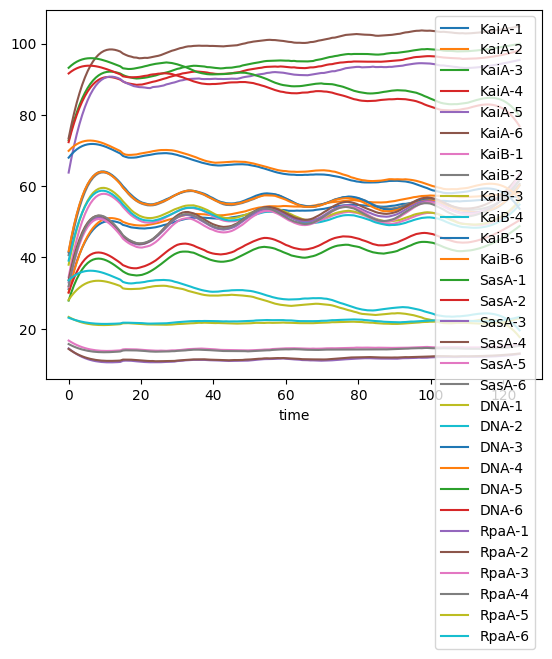

In [ ]:
dinner_smooth = dinner_df.copy()

dinner_smooth = dinner_smooth.iloc[::3, :]

window_length = 40
polyorder = 3

dinner_smooth.iloc[:, 1:] = savgol_filter(x = dinner_smooth.iloc[:, 1:].T,
                                          window_length = window_length,
                                          polyorder = polyorder).T

dinner_smooth = np.trunc(dinner_smooth * 1000) / 1000

dinner_smooth.plot(x = 'time')

In [ ]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dmatrix], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0 = theta[0, :]
    r = theta[1, :]
    AX = theta[2, :]

    return odeint(func=gLV, y0=X0,
                  t=dinner_smooth.time,
                  args=(r, AX,))



def gLV(X, t, r, AX):
    return X * (r + AX)

In [ ]:
# theta_glv4 = results_glv4.x  # least squares solution used to inform the priors
n = dinner_smooth.shape[1] - 1
with pm.Model() as model:

    priors = []

    # Params for X0
    X0 = pm.Uniform("X0",
                    lower=0,
                    upper=120,
                    shape=n)
    priors.append(X0)

    # Params for r
    r = pm.Normal("r",
                  mu=0,
                  sigma=2,
                  shape=n)
    priors.append(r)


    # Params for A
    A = pm.Normal("A",
                  mu=0,
                  sigma=5,
                  shape=(n, n))

    AX = pm.Deterministic(name = "AX", var = pm.math.dot(A, X0))
    priors.append(AX)

    # # Priors
    # alpha = pm.TruncatedNormal("alpha", mu=theta_glv2[0], sigma=0.1, lower=0, initval=theta_glv2[0])
    # beta = pm.TruncatedNormal("beta", mu=theta_glv2[1], sigma=0.01, lower=0, initval=theta_glv2[1])
    # gamma = pm.TruncatedNormal("gamma", mu=theta_glv2[2], sigma=0.1, lower=0, initval=theta_glv2[2])
    # delta = pm.TruncatedNormal("delta", mu=theta_glv2[3], sigma=0.01, lower=0, initval=theta_glv2[3])
    # xt0 = pm.TruncatedNormal("xto", mu=theta_glv2[4], sigma=1, lower=0, initval=theta_glv2[4])
    # yt0 = pm.TruncatedNormal("yto", mu=theta_glv2[5], sigma=1, lower=0, initval=theta_glv2[5])
    sigma = pm.HalfNormal("sigma", 2)



    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=dinner_smooth.iloc[:, 1:].values)

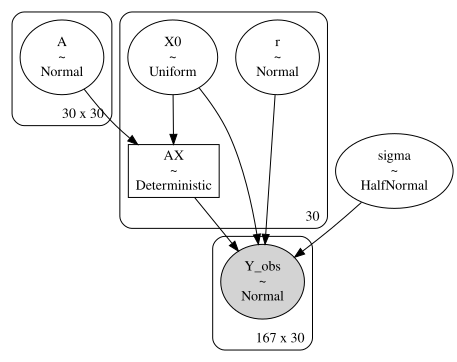

In [ ]:
pm.model_to_graphviz(model)

In [ ]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 100

# Inference!
with model:
    trace_slice = pm.sample(step=[pm.Slice(vars_list)],
                            draws=draws,
                            progressbar = True)

trace = trace_slice
az_trace = az.summary(trace)
az_trace

 Progress                          Draws   Tuning   Steps out   Steps in   Sampling Speed   Elapsed    Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   1       True     0           0          117.52 s/draws   22:31:00   -:--:--    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0       True     0           0          0.00 draws/s     22:31:00   -:--:--    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   1100    False    0           0          55.52 s/draws    16:56:52   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0       True     6           0          0.00 draws/s     22:31:00   -:--:--

# Appendix

In [ ]:
# theta_glv4 = results_glv4.x  # least squares solution used to inform the priors
# n = len(X0)
# with pm.Model() as model:

#     priors = []

#     # Params for X0
#     for i in range(n):

#       prior = pm.TruncatedNormal(f"x{i}",
#                                 mu=X0[i],
#                                 sigma=0.1,
#                                 lower=0,
#                                 initval=X0[i])
#       priors.append(prior)

#     # Params for r
#     for i in range(n):
#       prior = pm.TruncatedNormal(f"r{i}",
#                                 mu=rsim[i],
#                                 sigma=0.1,
#                                 lower=0,
#                                 initval=rsim[i])
#       priors.append(prior)


#     # Params for A
#     for k in range(n * n):
#       # row and column indexes
#       i, j = k // n, k % n

#       prior = pm.TruncatedNormal(f"A({i}, {j})",
#                                 mu=Asim[i, j],
#                                 sigma=0.1,
#                                 lower=0,
#                                 initval=Asim[i, j])
#       priors.append(prior)

#     # # Priors
#     # alpha = pm.TruncatedNormal("alpha", mu=theta_glv2[0], sigma=0.1, lower=0, initval=theta_glv2[0])
#     # beta = pm.TruncatedNormal("beta", mu=theta_glv2[1], sigma=0.01, lower=0, initval=theta_glv2[1])
#     # gamma = pm.TruncatedNormal("gamma", mu=theta_glv2[2], sigma=0.1, lower=0, initval=theta_glv2[2])
#     # delta = pm.TruncatedNormal("delta", mu=theta_glv2[3], sigma=0.01, lower=0, initval=theta_glv2[3])
#     # xt0 = pm.TruncatedNormal("xto", mu=theta_glv2[4], sigma=1, lower=0, initval=theta_glv2[4])
#     # yt0 = pm.TruncatedNormal("yto", mu=theta_glv2[5], sigma=1, lower=0, initval=theta_glv2[5])
#     sigma = pm.HalfNormal("sigma", 2)

#     # Ode solution function for Lotka-Volterra
#     ode_solution = pytensor_forward_model_matrix(
#         pm.math.stack(priors)
#     )

#     # Likelihood
#     pm.Normal("Y_obs",
#               mu=ode_solution,
#               sigma=sigma,
#               observed=df_4glv[["hare", "lynx", "fox", "wolf"]].values)

In [ ]:
# # Define the Lotka-Volterra model for 4 species
# def lotka_volterra(t, X, r, A):
#     return X * (r + A @ X)

# # Define parameters
# r_true = np.array([0.5, 0.3, 0.4, 0.2])  # Growth rates

# # Interaction matrix (randomly chosen stable values)
# A_true = np.array([
#     [-1.0,  0.5, -0.2,  0.3],
#     [ 0.2, -1.0,  0.4, -0.5],
#     [-0.3,  0.2, -1.0,  0.1],
#     [ 0.1, -0.4,  0.3, -1.0]
# ])

# X0 = np.array([10, 5, 8, 6])  # Initial populations

# # Simulate time series data
# t_span = (0, 50)
# t_eval = np.linspace(t_span[0], t_span[1], 100)
# sol = solve_ivp(lotka_volterra, t_span, X0, args=(r_true, A_true), t_eval=t_eval)
# X_obs = sol.y.T + np.random.normal(0, 0.5, sol.y.T.shape)  # Add noise

In [ ]:
# time.shape

(300,)

In [ ]:
# ?solve_ivp

In [ ]:
# # Bayesian Inference with PyMC
# with pm.Model() as model:
#     # Priors for parameters
#     r = pm.Normal("r", mu=0.5, sigma=0.3, shape=4)
#     A = pm.Normal("A", mu=0.0, sigma=0.5, shape=(4, 4))

#     # Solve Lotka-Volterra ODE with these parameters
#     def simulate_lv(r, A):
#         sol = solve_ivp(fun = gLV,
#                         y0 = X0,
#                         t_span = (time[0], time[-1]),
#                         args=(r, A),
#                         t_eval=time)
#         return sol.y.T

#     X_sim = pm.Deterministic("X_sim", simulate_lv(r, A))

#     # Likelihood (Observed data)
#     sigma = pm.HalfNormal("sigma", sigma=0.5)
#     Y_obs = pm.Normal("Y_obs", mu=X_sim, sigma=sigma, observed=data_4glv)

#     # Sampling
#     trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

# # Posterior Analysis
# az.plot_posterior(trace, var_names=["r"])
# plt.show()

# # Plot Predicted vs Observed
# plt.figure(figsize=(10, 5))
# for i in range(4):
#     plt.plot(t_eval, data_4glv[:, i], "o", label=f"Observed Species {i+1}")
#     plt.plot(t_eval, az.extract(trace)["X_sim"].mean(axis=0)[:, i], label=f"Predicted Species {i+1}")
# plt.xlabel("Time")
# plt.ylabel("Population")
# plt.title("Posterior Predictive Check")
# plt.legend()
# plt.grid()
# plt.show()

TypeError: solve_ivp() missing 1 required positional argument: 't_span'